# Multi-Class Depression Type Classification from Social Media Text

A complete deep learning pipeline for classifying depression types from social media posts using transformer models.

---

## Overview

This notebook implements an end-to-end pipeline for multi-class depression classification:

- **Task**: Classify social media posts into 5 depression types
- **Classes**: Atypical, Bipolar, Major Depressive, Postpartum, Psychotic
- **Models**: TF-IDF+SVM (baseline), MentalBERT, Twitter-RoBERTa
- **Dataset**: 14,996 labeled tweets from Zenodo

---

## Quick Start

**To run the entire pipeline:**
1. Click **Cell → Run All** (or **Restart & Run All**)
2. Expected runtime: **~5-10 minutes**
3. All dependencies will be installed automatically

**Requirements:**
- Python 3.8+
- GPU recommended (8GB+ VRAM)
- 16GB RAM minimum
- Internet connection (for dataset download)

---

## Dataset

**Source**: [Zenodo Multi-Class Depression Detection Dataset](https://doi.org/10.5281/zenodo.14233292)

- **Size**: 14,996 labeled tweets
- **Citation**: Nusrat, M.O. (2024). Multi-Class Depression Detection Dataset (v1.0). Zenodo.
- **License**: CC BY 4.0
- **Auto-downloaded**: The dataset is automatically downloaded when running this notebook

---

## Pipeline Structure

This notebook contains 4 main parts:

### **Part 1: EDA & Preprocessing**
- Load dataset from Zenodo
- Exploratory data analysis
- Text cleaning and preprocessing
- Train/val/test split (70/15/15%)

### **Part 2: Baseline ML Model**
- TF-IDF feature extraction
- Support Vector Machine (SVM)
- Performance baseline (~76% F1)

### **Part 3: MentalBERT Fine-tuning**
- Domain-specific transformer (mental health)
- Pre-optimized hyperparameters (20 epochs)
- **F1-Macro: ~0.84**

### **Part 4: Twitter-RoBERTa Fine-tuning**
- Social media-specific transformer
- Pre-optimized hyperparameters (20 epochs)
- **F1-Macro: ~0.83**

---

**Note**: Performance metrics shown are from full 20-epoch training. This notebook uses `epochs=1` for fast demonstration.

---

## Hyperparameters (Pre-optimized with Optuna)

**MentalBERT** (20 epochs, F1-Macro: 0.8443):
- Learning rate: 2.46e-05
- Batch size: 8
- Weight decay: 0.0787
- Warmup ratio: 0.123

**Twitter-RoBERTa** (20 epochs, F1-Macro: 0.8357):
- Learning rate: 3.82e-05
- Batch size: 8
- Weight decay: 0.0304
- Warmup ratio: 0.105

---

## Usage Notes

- **All random seeds are fixed** (SEED=42) for reproducibility
- **Optuna hyperparameter tuning is commented out** (pre-optimized values used)
- **Comparison between models is commented out**
- **Dataset auto-downloads** from Zenodo URL

---


In [ ]:
#if there is a cuda error, (cuda is not getting detected), run this code block and the one below it
# Uninstall existing torch and reinstall with CUDA support

#!pip uninstall -y torch torchvision torchaudio
#!pip install torch==2.2.2 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --break-system-packages

In [ ]:
#if there is a cuda error, (cuda is not getting detected), run this code block after running the one above
'''
import torch

print(f"PyTorch version: {torch._version_}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("Running on CPU")
'''

In [2]:
# Install all required packages
!pip install -q pandas numpy matplotlib seaborn wordcloud nltk scikit-learn \
    torch transformers datasets accelerate evaluate optuna lime textblob \
    contractions emoji tqdm
!pip install tf-keras --break-system-packages --quiet

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF warnings

# Prevent transformers from trying to import TensorFlow components
os.environ['TRANSFORMERS_NO_TF'] = '1'

print("Environment configured to skip TensorFlow imports")

✓ Environment configured to skip TensorFlow imports


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import random
import re

# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

# Statistical tests
from scipy.stats import chisquare, f_oneway, kruskal, mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

# NLP libraries
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import emoji
import contractions

# PyTorch and Transformers (PyTorch-only mode)
import torch

# Import transformers components individually to avoid TF dependencies
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

# Utilities
from tqdm.auto import tqdm
from huggingface_hub import login
import optuna
from lime.lime_text import LimeTextExplainer
import pickle
import json
import shutil
from math import pi
from matplotlib.gridspec import GridSpec

# Suppress additional warnings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print('Environment setup complete!')
print(f'Random seed: {SEED}')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

✓ Environment setup complete!
✓ Random seed: 42
✓ Device: cuda
✓ PyTorch version: 2.2.2+cu118
✓ GPU: Tesla T4


In [5]:
# Load dataset from Zenodo
# Note: If direct download fails, manually download from:
# https://zenodo.org/records/14233292 and update the path below

import urllib.request
import os

dataset_url = 'https://zenodo.org/records/14233292/files/dataset.csv?download=1'
dataset_path = 'dataset.csv'

# Try to download if not exists
if not os.path.exists(dataset_path):
    try:
        print('Downloading dataset from Zenodo...')
        urllib.request.urlretrieve(dataset_url, dataset_path)
        print('Dataset downloaded successfully')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Please manually download from: https://zenodo.org/records/14233292')
        print('And place dataset.csv in the same directory as this notebook')
        raise

# Load dataset
df = pd.read_csv(dataset_path)

print(f'\nDataset loaded: {len(df):,} samples')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst few rows:')
df.head()



Dataset loaded: 14,996 samples
Columns: ['Tweets', 'Labels']

First few rows:


,Tweets,Labels
0,I been going thru depression I didnt even rea...,postpartum
1,"@keshab_mahanta hello Health minister sir,I m ...",postpartum
2,FYI in case anyone is concerned - I am NOT act...,postpartum
3,@victorr_ugo Thankful I am able to hold my bab...,postpartum
4,I think I might be suffering from depression ...,postpartum


# PART 1: EXPLORATORY DATA ANALYSIS & PREPROCESSING

EDA

In [6]:
"""
1.1: LOAD DATASET
"""
df = pd.read_csv('dataset.csv')

print(f"\nDataset loaded: {len(df):,} samples")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 3 samples:")
print(df.head(3))


Dataset loaded: 14,996 samples
Columns: ['Tweets', 'Labels']

First 3 samples:
                                              Tweets      Labels
0  I been going thru depression  I didnt even rea...  postpartum
1  @keshab_mahanta hello Health minister sir,I m ...  postpartum
2  FYI in case anyone is concerned - I am NOT act...  postpartum


In [7]:
"""
1.2: DATA CLEANING
"""

print(f"\nOriginal dataset size: {len(df):,}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove rows with missing values
df_clean = df.dropna()
print(f"\nAfter removing NaN: {len(df_clean):,} samples")

# Check unique labels BEFORE filtering
print(f"\nUnique labels before filtering: {sorted(df_clean['Labels'].unique())}")

# Remove 'no' class (non-depression class)
df_clean = df_clean[df_clean['Labels'] != 'no']
print(f"After removing 'no' class: {len(df_clean):,} samples")

# Reset index AFTER filtering
df_clean = df_clean.reset_index(drop=True)

# Check unique labels AFTER filtering
print(f"\nFinal unique labels: {sorted(df_clean['Labels'].unique())}")
print(f"Number of depression types: {df_clean['Labels'].nunique()}")

# Rename for consistency
df_clean = df_clean.rename(columns={'Tweets': 'text', 'Labels': 'label'})

print("\nCleaned dataset info:")
print(df_clean.info())

# Use cleaned dataset from now on
df = df_clean


Original dataset size: 14,996

Missing values:
Tweets     1
Labels    12
dtype: int64

After removing NaN: 14,983 samples

Unique labels before filtering: ['atypical', 'bipolar', 'major depressive', 'no', 'postpartum', 'psychotic']
After removing 'no' class: 12,998 samples

Final unique labels: ['atypical', 'bipolar', 'major depressive', 'postpartum', 'psychotic']
Number of depression types: 5

Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12998 entries, 0 to 12997
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    12998 non-null  object
 1   label   12998 non-null  object
dtypes: object(2)
memory usage: 203.2+ KB
None



Class Distribution:
   atypical            :  1980 (15.23%)
   bipolar             :  2443 (18.80%)
   major depressive    :  2517 (19.36%)
   postpartum          :  3746 (28.82%)
   psychotic           :  2312 (17.79%)
   TOTAL               : 12998 (100.00%)

Imbalance Ratio: 1.89:1
Most frequent: postpartum (3746 samples)
Least frequent: atypical (1980 samples)

Chi-Square Test (Uniform Distribution):
Chi-square: 697.11, P-value: 1.4751e-149
Distribution is significantly NON-UNIFORM (p < 0.05)


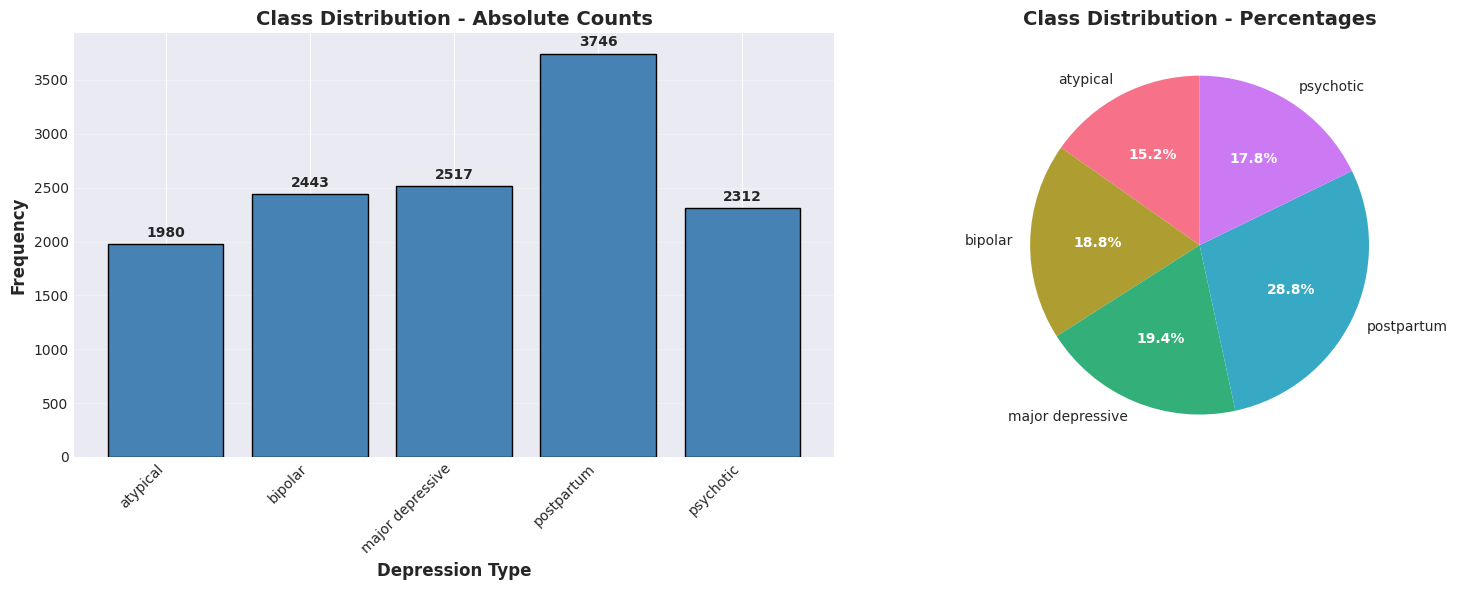

In [8]:
"""
1.3: CLASS DISTRIBUTION ANALYSIS
"""
# Calculate class distribution
class_counts = df['label'].value_counts().sort_index()
class_percentages = (class_counts / len(df) * 100).round(2)

print("\nClass Distribution:")
for label, count in class_counts.items():
    pct = class_percentages[label]
    print(f"   {label:20s}: {count:5d} ({pct:5.2f}%)")
print(f"   {'TOTAL':20s}: {class_counts.sum():5d} (100.00%)")

# Imbalance analysis
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Most frequent: {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Least frequent: {class_counts.idxmin()} ({class_counts.min()} samples)")

# Statistical test
expected_freq = len(df) / len(class_counts)
chi_stat, p_value = chisquare(class_counts.values)
print(f"\nChi-Square Test (Uniform Distribution):")
print(f"Chi-square: {chi_stat:.2f}, P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Distribution is significantly NON-UNIFORM (p < 0.05)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].bar(range(len(class_counts)), class_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Depression Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution - Absolute Counts', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, count in enumerate(class_counts.values):
    axes[0].text(i, count + max(class_counts)*0.01, str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = sns.color_palette("husl", len(class_counts))
wedges, texts, autotexts = axes[1].pie(
    class_counts.values, 
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title('Class Distribution - Percentages', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()


Overall Statistics:
Characters - Mean: 178.3, Median: 173.0
Words - Mean: 32.2, Median: 32.0

Per-Class Statistics:
Class                Char Mean       Word Mean       Char Median     Word Median    
atypical             164.1           28.5            163.5           28.0           
bipolar              174.2           31.5            157.0           29.0           
major depressive     193.7           34.2            197.0           35.0           
postpartum           173.8           32.7            166.0           31.0           
psychotic            185.2           33.4            187.0           34.0           


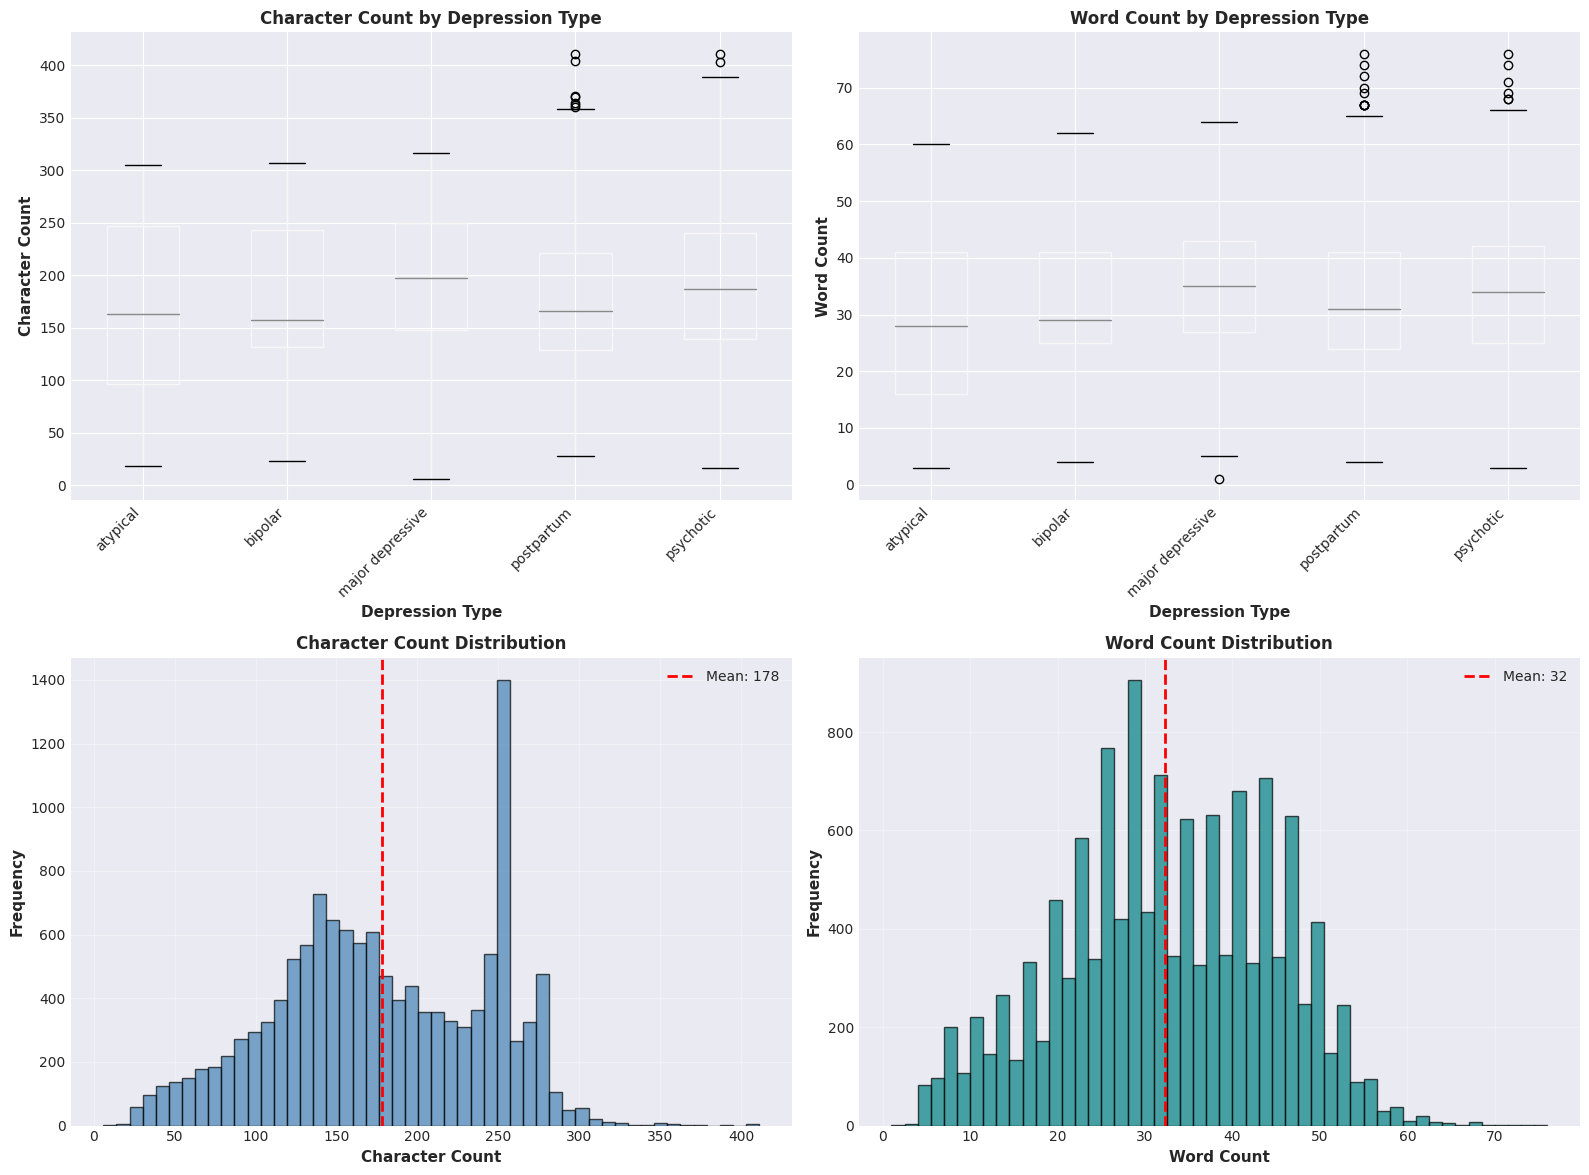

In [9]:
"""
1.4: TEXT LENGTH ANALYSIS
"""
# Calculate text lengths
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\nOverall Statistics:")
print(f"Characters - Mean: {df['char_count'].mean():.1f}, Median: {df['char_count'].median():.1f}")
print(f"Words - Mean: {df['word_count'].mean():.1f}, Median: {df['word_count'].median():.1f}")

print("\nPer-Class Statistics:")
print(f"{'Class':<20} {'Char Mean':<15} {'Word Mean':<15} {'Char Median':<15} {'Word Median':<15}")

for label in sorted(df['label'].unique()):
    subset = df[df['label'] == label]
    print(f"{label:<20} {subset['char_count'].mean():<15.1f} {subset['word_count'].mean():<15.1f} "
          f"{subset['char_count'].median():<15.1f} {subset['word_count'].median():<15.1f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plots
df.boxplot(column='char_count', by='label', ax=axes[0, 0])
axes[0, 0].set_title('Character Count by Depression Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Depression Type', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Character Count', fontsize=11, fontweight='bold')
axes[0, 0].get_figure().suptitle('')
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

df.boxplot(column='word_count', by='label', ax=axes[0, 1])
axes[0, 1].set_title('Word Count by Depression Type', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Depression Type', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Word Count', fontsize=11, fontweight='bold')
axes[0, 1].get_figure().suptitle('')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Histograms
axes[1, 0].hist(df['char_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['char_count'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df["char_count"].mean():.0f}')
axes[1, 0].set_title('Character Count Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Character Count', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df['word_count'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df["word_count"].mean():.0f}')
axes[1, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Word Count', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
"""
1.5: VOCABULARY ANALYSIS
"""
# Overall vocabulary analysis 
all_text = ' '.join(df['text'].values)
all_words = all_text.lower().split()
vocab_size = len(set(all_words))
total_words = len(all_words)

print(f"\nOverall Vocabulary:")
print(f"Total words: {total_words:,}")
print(f"Unique words: {vocab_size:,}")
print(f"Lexical diversity: {vocab_size/total_words:.4f}")

print(f"\nPer-Class Vocabulary:")
print(f"{'Class':<20} {'Total Words':<15} {'Unique Words':<15} {'Diversity':<15}")

for label in sorted(df['label'].unique()):
    class_text = ' '.join(df[df['label'] == label]['text'].values)
    class_words = class_text.lower().split()
    class_vocab = len(set(class_words))
    class_total = len(class_words)
    class_diversity = class_vocab / class_total if class_total > 0 else 0
    print(f"{label:<20} {class_total:<15,} {class_vocab:<15,} {class_diversity:<15.4f}")

word_freq = Counter(all_words)
print(f"\nTop 20 Most Frequent Words:")
for word, count in word_freq.most_common(20):
    print(f"{word:<20} {count:>6,}")

print("\nTop 10 Words Per Class:")
for label in sorted(df['label'].unique()):
    print(f"\n{label}:")
    class_text = ' '.join(df[df['label'] == label]['text'].values)
    class_words = class_text.lower().split()
    class_freq = Counter(class_words)
    
    for word, count in class_freq.most_common(10):
        print(f"{word:<20} {count:>6,}")


Overall Vocabulary:
Total words: 419,150
Unique words: 27,330
Lexical diversity: 0.0652

Per-Class Vocabulary:
Class                Total Words     Unique Words    Diversity      
atypical             56,416          9,049           0.1604         
bipolar              76,852          9,808           0.1276         
major depressive     86,121          9,990           0.1160         
postpartum           122,605         8,290           0.0676         
psychotic            77,156          7,314           0.0948         

Top 20 Most Frequent Words:
i                    25,038
and                  12,435
to                   11,960
a                     9,506
the                   9,105
have                  8,713
my                    8,338
like                  8,311
of                    6,511
i'm                   6,485
it's                  4,756
in                    4,537
is                    4,236
but                   4,171
that                  3,938
feel                  3,6

Keyword taxonomy loaded: 336 terms across 7 categories
Categories: Emotional, Cognitive, Physical, Social, Suicidal, Treatment, Temporal

Number of posts containing at least one keyword from each category

           Class atypical  Class bipolar  Class major depressive  \
Emotional             447            534                     719   
Cognitive             302            462                     595   
Physical             1045            304                     463   
Social                237            540                     498   
Suicidal               68            199                     250   
Treatment             351            463                     580   
Temporal              402            528                     626   

           Class postpartum  Class psychotic  
Emotional              2300             1314  
Cognitive              1120              892  
Physical                839              546  
Social                  898              516  
Suicidal      

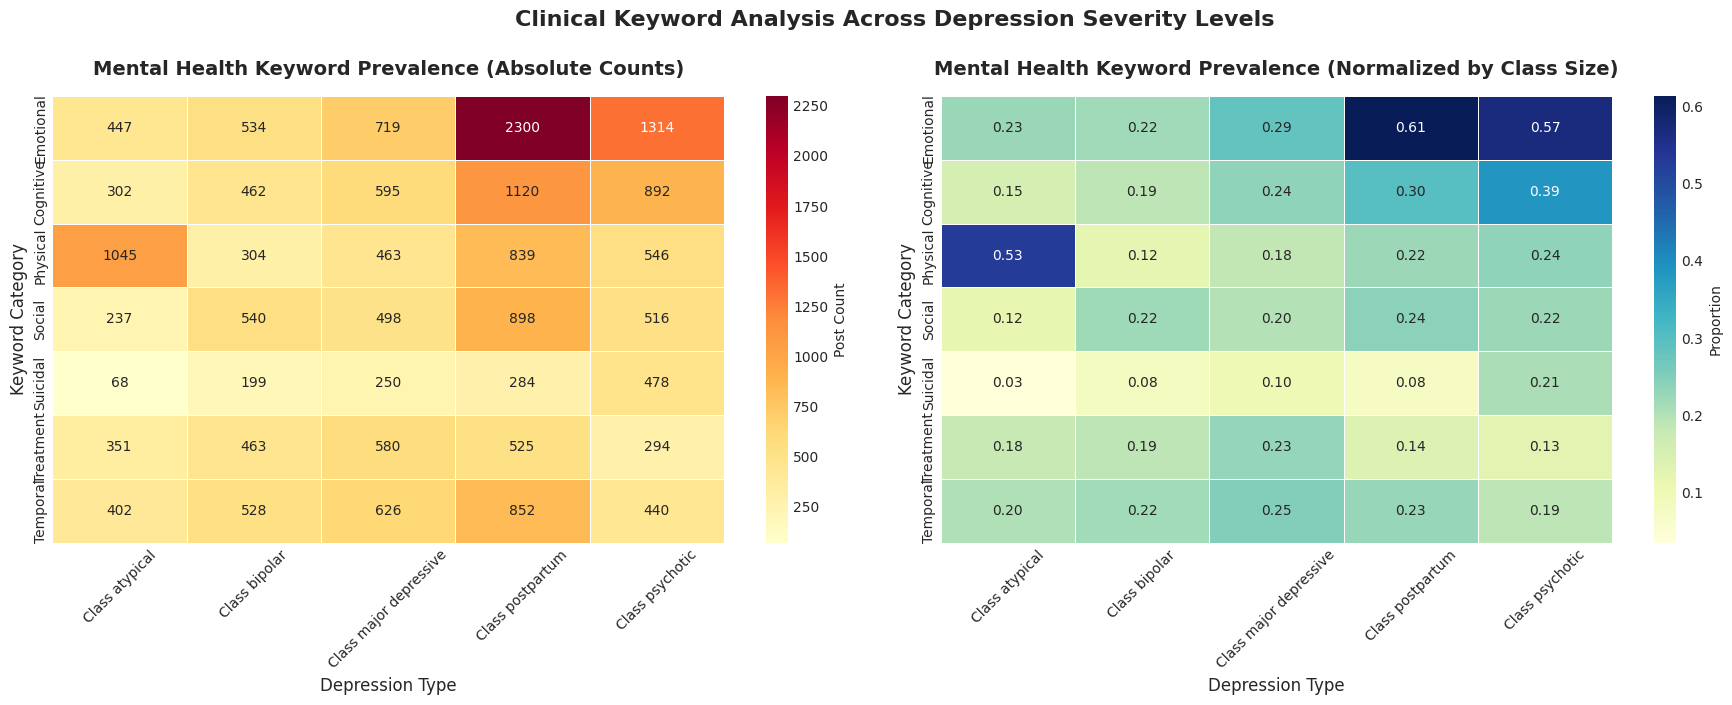

In [11]:
"""
1.6: MENTAL HEALTH KEYWORD ANALYSIS
"""

# ══════════════════════════════════════════════════════════════════════════════
# CLINICAL KEYWORD TAXONOMY
# ══════════════════════════════════════════════════════════════════════════════

mental_health_keywords = {
    # ══════════════════════════════════════════════════════════════════
    # CORE EMOTIONAL SYMPTOMS (DSM-5 Criterion A)
    # ══════════════════════════════════════════════════════════════════
    'Emotional': [
        # Depressed mood indicators
        'sad', 'sadness', 'empty', 'emptiness', 'hopeless', 'hopelessness',
        'worthless', 'worthlessness', 'guilty', 'guilt', 'depressed', 'depression',
        'down', 'low', 'miserable', 'unhappy', 'grief', 'despair', 'numb', 'numbness',
        'void', 'broken', 'crushed', 'devastated', 'defeated',
        
        # Anhedonia (loss of interest/pleasure)
        'nothing', 'pointless', 'meaningless', 'flat', 'dull',
        'nothingness', 'unfeeling',
        
        # Emotional dysregulation
        'crying', 'tears', 'weeping', 'sobbing', 'overwhelmed', 'emotional',
        'fragile', 'sensitive', 'irritable', 'angry', 'rage', 'frustrated'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # COGNITIVE SYMPTOMS (Concentration & Decision-Making Impairment)
    # ══════════════════════════════════════════════════════════════════
    'Cognitive': [
        # Concentration difficulties
        'think', 'thinking', 'concentrate', 'concentration', 'focus', 'focusing',
        'attention', 'distracted', 'foggy', 'fog', 'brain fog', 'haze',
        
        # Decision-making impairment
        'decide', 'decision', 'indecisive', 'confused', 'confusion', 'lost',
        'stuck', 'paralyzed', 'frozen',
        
        # Memory issues
        'memory', 'forget', 'forgetting', 'forgotten', 'remember', 'remembering',
        'recall', 'blank',
        
        # Rumination & intrusive thoughts
        'mind', 'thoughts', 'racing', 'race', 'overthinking',
        'ruminating', 'rumination', 'obsessing', 'repetitive', 'loops', 'spiraling',
        'slow', 'slowed', 'sluggish',
        
        # Negative cognitive patterns
        'failure', 'failed', 'failing', 'mistake', 'mistakes', 'stupid',
        'useless', 'burden', 'pathetic', 'loser', 'waste'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # PHYSICAL/SOMATIC SYMPTOMS (Neurovegetative Signs)
    # ══════════════════════════════════════════════════════════════════
    'Physical': [
        # Fatigue & energy depletion
        'tired', 'tiredness', 'fatigue', 'fatigued', 'exhausted', 'exhaustion',
        'drained', 'depleted', 'weak', 'weakness', 'energy', 'lethargic', 'lethargy',
        'sluggish', 'heavy', 'weary',
        
        # Sleep disturbances
        'sleep', 'sleeping', 'sleepless', 'insomnia', 'cant sleep', "can't sleep",
        'awake', 'sleepy', 'drowsy', 'oversleeping', 'bed', 'nap', 'napping',
        'nightmare', 'nightmares', 'restless',
        
        # Appetite & weight changes
        'appetite', 'hungry', 'hunger', 'eating', 'eat', 'food', 'weight',
        'gained', 'lost', 'overeating', 'starving', 'starve', 'binge',
        
        # Psychomotor symptoms
        'pain', 'ache', 'aching', 'aches', 'headache', 'headaches', 'hurt', 'hurting',
        'sore', 'tension', 'tight', 'chest', 'stomach', 'nausea', 'sick', 'ill',
        'dizzy', 'shaking', 'trembling', 'tingling'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # SOCIAL WITHDRAWAL & INTERPERSONAL DYSFUNCTION
    # ══════════════════════════════════════════════════════════════════
    'Social': [
        # Isolation & loneliness
        'alone', 'lonely', 'loneliness', 'isolated', 'isolation', 'isolating',
        'withdrawn', 'withdrawing', 'nobody', 'no one',
        
        # Social connections
        'friends', 'friend', 'family', 'people', 'everyone', 'anyone',
        'relationships', 'relationship', 'partner', 'loved ones',
        
        # Avoidance behaviors
        'avoid', 'avoiding', 'avoidance', 'hiding', 'hide', 'disappear',
        'cancel', 'cancelled', 'bail', 'bailed', 'flake', 'excuse', 'excuses',
        
        # Perceived rejection/abandonment
        'abandoned', 'reject', 'rejected', 'rejection', 'pushed away',
        'left', 'leaving', 'gone', 'distance', 'distant', 'disconnected',
        'invisible', 'ignored', 'neglected', 'unwanted'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # HIGH-RISK SUICIDAL IDEATION (CRITICAL for clinical screening)
    # ══════════════════════════════════════════════════════════════════
    'Suicidal': [
        # Direct suicidal language
        'suicide', 'suicidal', 'kill myself', 'killing myself', 'end it',
        'end my life', 'take my life', 'die', 'dying', 'death', 'dead',
        'better off dead', 'wish i was dead',
        
        # Methods & planning (high specificity)
        'overdose', 'pills', 'jump', 'jumping', 'bridge', 'cliff',
        'gun', 'shoot', 'hanging', 'rope', 'knife',
        
        # Self-harm behaviors
        'hurt myself', 'hurting myself', 'harm', 'harming', 'cut', 'cutting',
        'cutter', 'blade', 'burn', 'burning', 'scratch', 'scratching',
        'hitting', 'punching', 'bruise',
        
        # Ideation & intent markers
        'plan', 'planning', 'method', 'note', 'goodbye', 'final', 'last time',
        'give up', 'giving up', 'cant go on', "can't go on", 'no point',
        'no reason', 'escape', 'relief', 'peace', 'end the pain'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TREATMENT & HELP-SEEKING (Indicates awareness/engagement)
    # ══════════════════════════════════════════════════════════════════
    'Treatment': [
        # Professional help
        'therapy', 'therapist', 'counseling', 'counselor', 'psychiatrist',
        'psychologist', 'doctor', 'medication', 'meds', 'antidepressant',
        'antidepressants', 'ssri', 'prescription', 'diagnosed', 'diagnosis',
        
        # Specific medications (common antidepressants)
        'prozac', 'zoloft', 'lexapro', 'wellbutrin', 'cymbalta', 'effexor',
        'celexa', 'paxil', 'sertraline', 'fluoxetine', 'escitalopram',
        
        # Help-seeking & support
        'help', 'support', 'crisis', 'hotline', 'hospital', 'emergency',
        'admitted', 'ward', 'clinic', 'appointment', 'session'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TEMPORAL MARKERS (Duration & chronicity indicators)
    # ══════════════════════════════════════════════════════════════════
    'Temporal': [
        # Chronicity (persistent symptoms)
        'always', 'constantly', 'every day', 'everyday', 'daily', 'nonstop',
        'never ending', 'forever', 'chronic', 'persistent', 'ongoing',
        
        # Acute episodes
        'episode', 'relapse', 'relapsed', 'worse', 'worsening', 'spiral',
        'spiraling', 'downward', 'falling', 'crash', 'crashed',
        
        # Duration phrases
        'weeks', 'months', 'years', 'long time', 'ages', 'recently',
        'lately', 'today', 'tonight', 'right now'
    ]
}

# Total unique keywords across all categories
all_keywords = [word for category in mental_health_keywords.values() for word in category]
print(f"Keyword taxonomy loaded: {len(all_keywords)} terms across {len(mental_health_keywords)} categories")
print(f"Categories: {', '.join(mental_health_keywords.keys())}\n")

# ══════════════════════════════════════════════════════════════════════════════
# KEYWORD PREVALENCE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# Get unique depression type labels 
labels = sorted(df['label'].unique())
label_names = {0: 'atypical', 1: 'bipolar', 2: 'major depressive', 3: 'postpartum', 4:'psychotic' }

# Initialize results dictionary
keyword_counts = {category: {} for category in mental_health_keywords.keys()}

# Count posts containing at least one keyword from each category
# This avoids double-counting and length bias inherent in raw word frequency
for category, keywords in mental_health_keywords.items():
    for label in labels:
        # Filter to current depression type
        class_texts = df[df['label'] == label]['text'].str.lower()
        
        # Count posts where ANY keyword from this category appears
        # Uses word boundary regex to avoid partial matches (e.g., 'sad' in 'sadness')
        pattern = r'\b(?:' + '|'.join(re.escape(kw) for kw in keywords) + r')\b'
        posts_with_keyword = class_texts.str.contains(pattern, regex=True, na=False).sum()
        
        keyword_counts[category][label] = posts_with_keyword

keyword_df = pd.DataFrame(keyword_counts).T
keyword_df.columns = [label_names.get(label, f'Class {label}') for label in keyword_df.columns]

print("Number of posts containing at least one keyword from each category\n")
print(keyword_df)

# ──────────────────────────────────────────────────────────────────────────────
# NORMALIZE BY CLASS SIZE
# ──────────────────────────────────────────────────────────────────────────────
# Critical: Raw counts mislead when classes are imbalanced
# Normalized = (posts with keyword) / (total posts in class)

class_sizes = df['label'].value_counts().sort_index()
class_sizes.index = [label_names.get(label, f'Class {label}') for label in class_sizes.index]

# Divide each column by its class size to get proportion
keyword_df_normalized = keyword_df.div(class_sizes, axis=1)

print()
print("% of posts in each class containing keywords from each category\n")
print(keyword_df_normalized.round(3))
print()

# ──────────────────────────────────────────────────────────────────────────────
# CLINICAL INTERPRETATION
# ──────────────────────────────────────────────────────────────────────────────

# Identify category with highest increase from not depressed → severe
severity_gradient = keyword_df_normalized.iloc[:, -1] - keyword_df_normalized.iloc[:, 0]
top_gradient = severity_gradient.nlargest(3)

print(f"\nCategories showing strongest severity gradient (Not Depressed → Severe):")
for cat, increase in top_gradient.items():
    print(f"  • {cat}: +{increase:.1%} prevalence increase")

if 'Suicidal' in keyword_df_normalized.index:
    suicidal_rates = keyword_df_normalized.loc['Suicidal']
    print(f"\nSUICIDAL IDEATION PREVALENCE:")
    for class_name, rate in suicidal_rates.items():
        print(f"{class_name}: {rate:.1%} of posts")


# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Heatmap 1: Absolute Counts ──
sns.heatmap(keyword_df, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Post Count'}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Mental Health Keyword Prevalence (Absolute Counts)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Depression Type', fontsize=12)
axes[0].set_ylabel('Keyword Category', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# ── Heatmap 2: Normalized Proportions ──
sns.heatmap(keyword_df_normalized, annot=True, fmt='.2f', cmap='YlGnBu', 
            cbar_kws={'label': 'Proportion'}, ax=axes[1], linewidths=0.5)
axes[1].set_title('Mental Health Keyword Prevalence (Normalized by Class Size)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Depression Type', fontsize=12)
axes[1].set_ylabel('Keyword Category', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Clinical Keyword Analysis Across Depression Severity Levels', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [12]:
"""
1.7: DATA QUALITY CHECKS
"""
print("\nDuplicate Detection:")
n_duplicates = df.duplicated().sum()
print(f"Exact duplicates: {n_duplicates}")
if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {n_duplicates} duplicates")
    print(f"New dataset size: {len(df)}")

print("\nText Length Outliers:")
q1 = df['char_count'].quantile(0.25)
q3 = df['char_count'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['char_count'] < lower_bound) | (df['char_count'] > upper_bound)]
print(f"Outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Range: [{lower_bound:.0f}, {upper_bound:.0f}] characters")

print("\nEmpty/Very Short Texts:")
very_short = df[df['word_count'] < 3]
print(f"Texts < 3 words: {len(very_short)}")

print(f"Final dataset size: {len(df):,} samples")


Duplicate Detection:
Exact duplicates: 0

Text Length Outliers:
Outliers (IQR method): 2 (0.02%)
Range: [-32, 404] characters

Empty/Very Short Texts:
Texts < 3 words: 1
Final dataset size: 12,998 samples


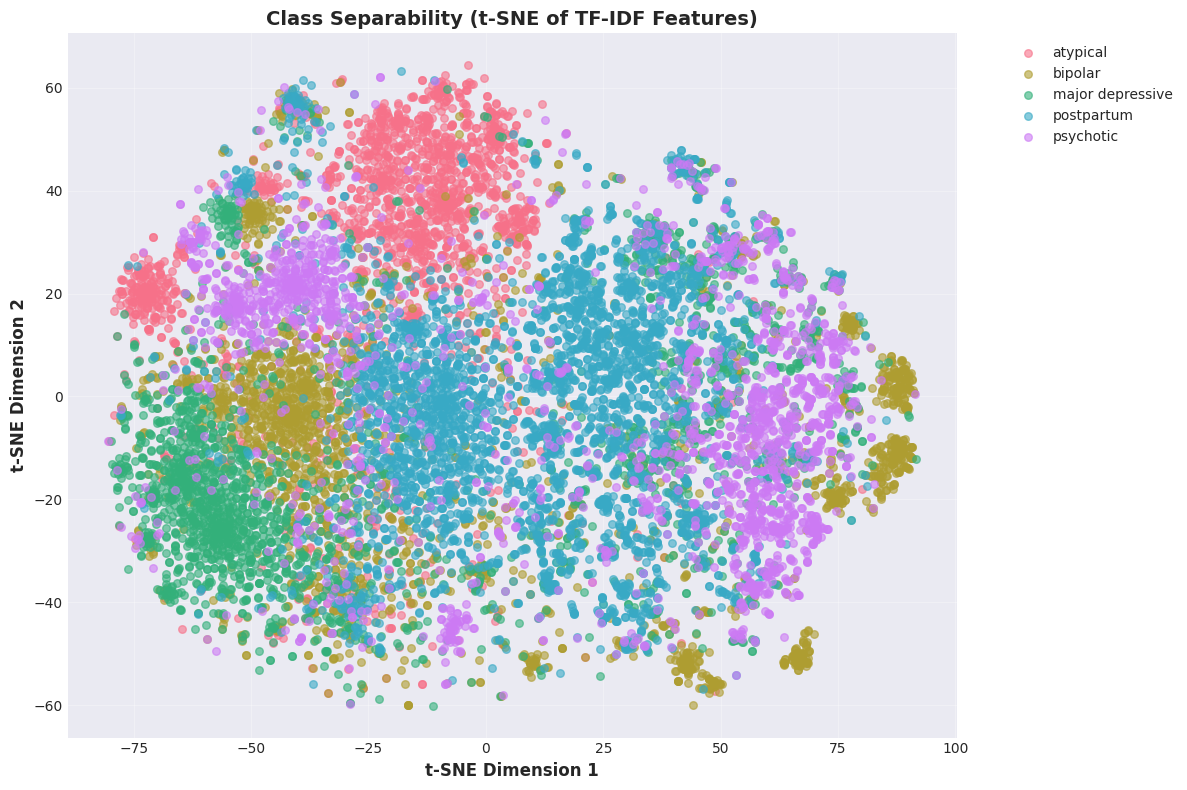

In [13]:
"""
1.8: CLASS SEPARABILITY VISUALIZATION
"""
tfidf = TfidfVectorizer(max_features=1000, min_df=2)
X_tfidf = tfidf.fit_transform(df['text'])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(12, 8))
colors = sns.color_palette("husl", df['label'].nunique())

for idx, label in enumerate(sorted(df['label'].unique())):
    mask = df['label'] == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                c=[colors[idx]], label=label, alpha=0.6, s=30)

plt.xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
plt.title('Class Separability (t-SNE of TF-IDF Features)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
"""
1.9: STATISTICAL HYPOTHESIS TESTING - TEXT LENGTH
"""
# ANOVA test: Are text lengths significantly different across classes?
class_groups = [df[df['label'] == label]['word_count'].values 
                for label in df['label'].unique()]

# Parametric test (ANOVA)
f_stat, p_value_anova = f_oneway(*class_groups)
print(f"\nOne-Way ANOVA (Word Count):")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   P-value: {p_value_anova:.4e}")

if p_value_anova < 0.05:
    print("Result: SIGNIFICANT difference in text lengths across classes (p < 0.05)")
else:
    print("Result: No significant difference")

# Non-parametric test (Kruskal-Wallis)
h_stat, p_value_kruskal = kruskal(*class_groups)
print(f"\nKruskal-Wallis Test (Word Count):")
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value_kruskal:.4e}")

# Pairwise comparisons (Effect sizes - Cohen's d)
print(f"\nPairwise Effect Sizes (Cohen's d):")

labels = sorted(df['label'].unique())

def cohens_d(group1, group2):
    #Calculate Cohen's d effect size
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    pooled_std = np.sqrt(((len(group1)-1)*std1**2 + (len(group2)-1)*std2**2) / 
                         (len(group1) + len(group2) - 2))
    return (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

effect_sizes = []

for label1, label2 in combinations(labels, 2):
    group1 = df[df['label'] == label1]['word_count'].values
    group2 = df[df['label'] == label2]['word_count'].values
    
    d = cohens_d(group1, group2)
    effect_sizes.append({
        'Comparison': f"{label1} vs {label2}",
        'Cohen_d': d,
        'Magnitude': 'Small' if abs(d) < 0.5 else 'Medium' if abs(d) < 0.8 else 'Large'
    })

effect_df = pd.DataFrame(effect_sizes).sort_values('Cohen_d', key=abs, ascending=False)
print(effect_df.to_string(index=False))


One-Way ANOVA (Word Count):
   F-statistic: 75.0095
   P-value: 5.7230e-63
Result: SIGNIFICANT difference in text lengths across classes (p < 0.05)

Kruskal-Wallis Test (Word Count):
H-statistic: 239.1456
P-value: 1.4172e-50

Pairwise Effect Sizes (Cohen's d):
                    Comparison   Cohen_d Magnitude
  atypical vs major depressive -0.457304     Small
         atypical vs psychotic -0.372284     Small
        atypical vs postpartum -0.339449     Small
   bipolar vs major depressive -0.244295     Small
           atypical vs bipolar -0.231377     Small
          bipolar vs psychotic -0.161846     Small
major depressive vs postpartum  0.131689     Small
         bipolar vs postpartum -0.110483     Small
 major depressive vs psychotic  0.073129     Small
       postpartum vs psychotic -0.054863     Small


In [15]:
"""
1.10: N-GRAM ANALYSIS - DISTINCTIVE PHRASES PER CLASS
"""
# Function to get top n-grams per class
def get_top_ngrams(corpus, n=2, top_k=15):
    #Extract top k n-grams from corpus
    vectorizer = CountVectorizer(ngram_range=(n, n), max_features=1000, 
                                 stop_words='english', min_df=2)
    ngram_matrix = vectorizer.fit_transform(corpus)
    ngram_counts = ngram_matrix.sum(axis=0).A1
    ngram_freq = [(word, ngram_counts[idx]) 
                  for word, idx in vectorizer.vocabulary_.items()]
    return sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:top_k]

# Analyze bigrams and trigrams per class
print("\nTOP DISTINCTIVE BIGRAMS PER CLASS:")

for label in sorted(df['label'].unique()):
    class_texts = df[df['label'] == label]['text'].tolist()
    
    print(f"\n{label.upper()}:")
    
    # Bigrams
    bigrams = get_top_ngrams(class_texts, n=2, top_k=10)
    print("Top Bigrams:")
    for i, (phrase, count) in enumerate(bigrams[:10], 1):
        print(f"   {i}. {phrase:30s} ({count:4d})")

print("\nTOP DISTINCTIVE TRIGRAMS PER CLASS:")

for label in sorted(df['label'].unique()):
    class_texts = df[df['label'] == label]['text'].tolist()
    
    print(f"\n{label.upper()}:")
    
    # Trigrams
    trigrams = get_top_ngrams(class_texts, n=3, top_k=8)
    print("Top Trigrams:")
    for i, (phrase, count) in enumerate(trigrams[:8], 1):
        print(f"   {i}. {phrase:40s} ({count:4d})")


TOP DISTINCTIVE BIGRAMS PER CLASS:

ATYPICAL:
Top Bigrams:
   1. idiopathic hypersomnia         ( 349)
   2. atypical depression            ( 308)
   3. insomnia hypersomnia           ( 108)
   4. sleep disorder                 (  89)
   5. fall asleep                    (  67)
   6. think hypersomnia              (  67)
   7. hypersomnia sleep              (  55)
   8. feel like                      (  54)
   9. hypersomnia sleepdisorder      (  52)
   10. hypersomnia insomnia           (  45)

BIPOLAR:
Top Bigrams:
   1. bipolar disorder               (1512)
   2. feel like                      ( 522)
   3. like way                       ( 476)
   4. like living                    ( 367)
   5. living constant                ( 168)
   6. constant state                 ( 167)
   7. feels like                     ( 136)
   8. living world                   ( 125)
   9. diagnosed bipolar              (  87)
   10. sadness feel                   (  84)

MAJOR DEPRESSIVE:
Top Bigrams:
   


Sentiment Polarity by Depression Type:
Class                Mean       Median     Std        Min        Max       
atypical             0.0280     0.0000     0.2590     -1.0000    1.0000    
bipolar              0.0192     0.0000     0.2395     -1.0000    1.0000    
major depressive     0.0295     0.0438     0.2026     -1.0000    0.8000    
postpartum           0.0524     0.0184     0.2837     -1.0000    1.0000    
psychotic            -0.1023    -0.0833    0.2642     -1.0000    0.7000    

ANOVA Test (Sentiment Polarity):
F-statistic: 145.9407
P-value: 2.8203e-122
Result: SIGNIFICANT difference in sentiment across classes


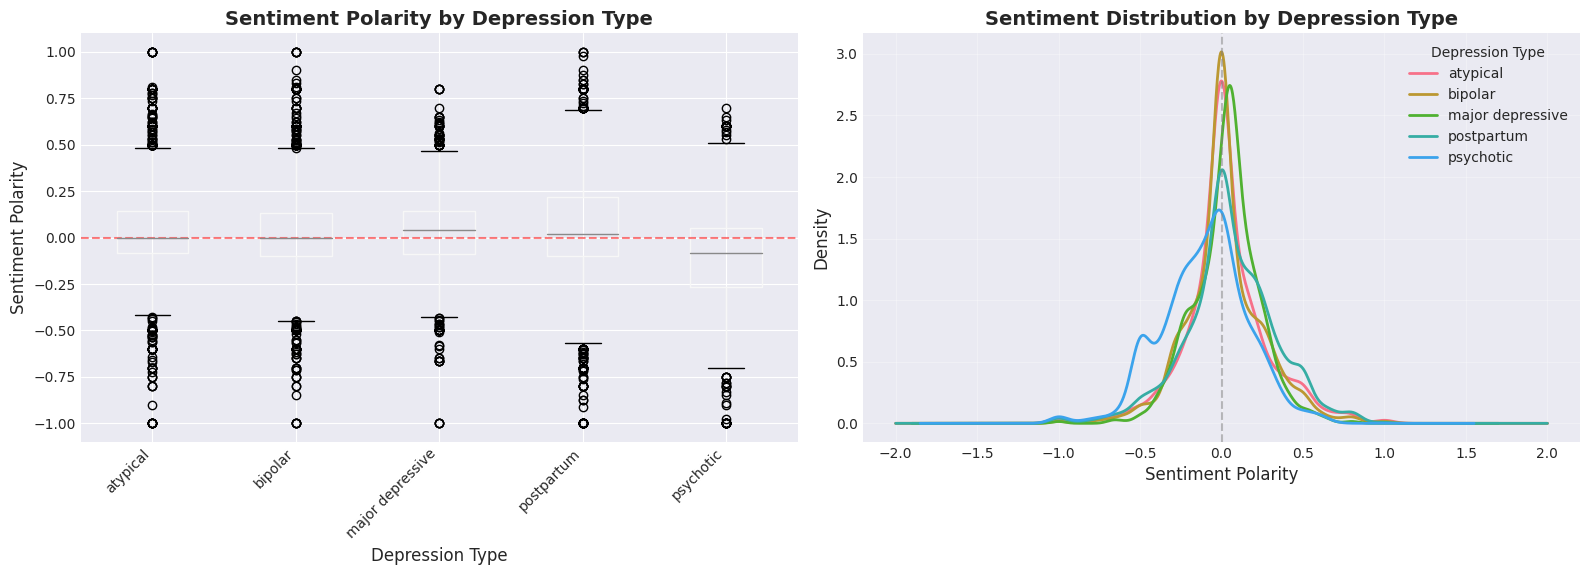

In [16]:
"""
1.11: SENTIMENT & EMOTIONAL TONE ANALYSIS
"""
# Calculate sentiment polarity per text
def get_sentiment(text):
    #Get sentiment polarity using TextBlob
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0.0

df['sentiment'] = df['text'].apply(get_sentiment)

# Per-class sentiment statistics
print("\nSentiment Polarity by Depression Type:")
print(f"{'Class':<20} {'Mean':<10} {'Median':<10} {'Std':<10} {'Min':<10} {'Max':<10}")

for label in sorted(df['label'].unique()):
    sentiment_values = df[df['label'] == label]['sentiment']
    print(f"{label:<20} {sentiment_values.mean():<10.4f} "
          f"{sentiment_values.median():<10.4f} {sentiment_values.std():<10.4f} "
          f"{sentiment_values.min():<10.4f} {sentiment_values.max():<10.4f}")

# Statistical test: Do sentiment scores differ across classes?
sentiment_groups = [df[df['label'] == label]['sentiment'].values 
                    for label in df['label'].unique()]
f_stat, p_value = f_oneway(*sentiment_groups)

print(f"\nANOVA Test (Sentiment Polarity):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: SIGNIFICANT difference in sentiment across classes")

# Visualization: Sentiment distribution per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
df.boxplot(column='sentiment', by='label', ax=axes[0])
axes[0].set_title('Sentiment Polarity by Depression Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depression Type', fontsize=12)
axes[0].set_ylabel('Sentiment Polarity', fontsize=12)
axes[0].get_figure().suptitle('')
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Neutral')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# KDE plot (overlaid distributions)
for label in sorted(df['label'].unique()):
    sentiment_values = df[df['label'] == label]['sentiment']
    sentiment_values.plot(kind='kde', ax=axes[1], label=label, linewidth=2)

axes[1].set_title('Sentiment Distribution by Depression Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment Polarity', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].legend(title='Depression Type')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Pronoun Usage Ratios by Depression Type:
Class                1st Person      2nd Person      3rd Person     
atypical             0.1077          0.0055          0.0033         
bipolar              0.0836          0.0053          0.0045         
major depressive     0.0817          0.0054          0.0036         
postpartum           0.1041          0.0038          0.0060         
psychotic            0.0845          0.0039          0.0041         

ANOVA Test (First-Person Pronoun Usage):
F-statistic: 152.0670
P-value: 2.3961e-127


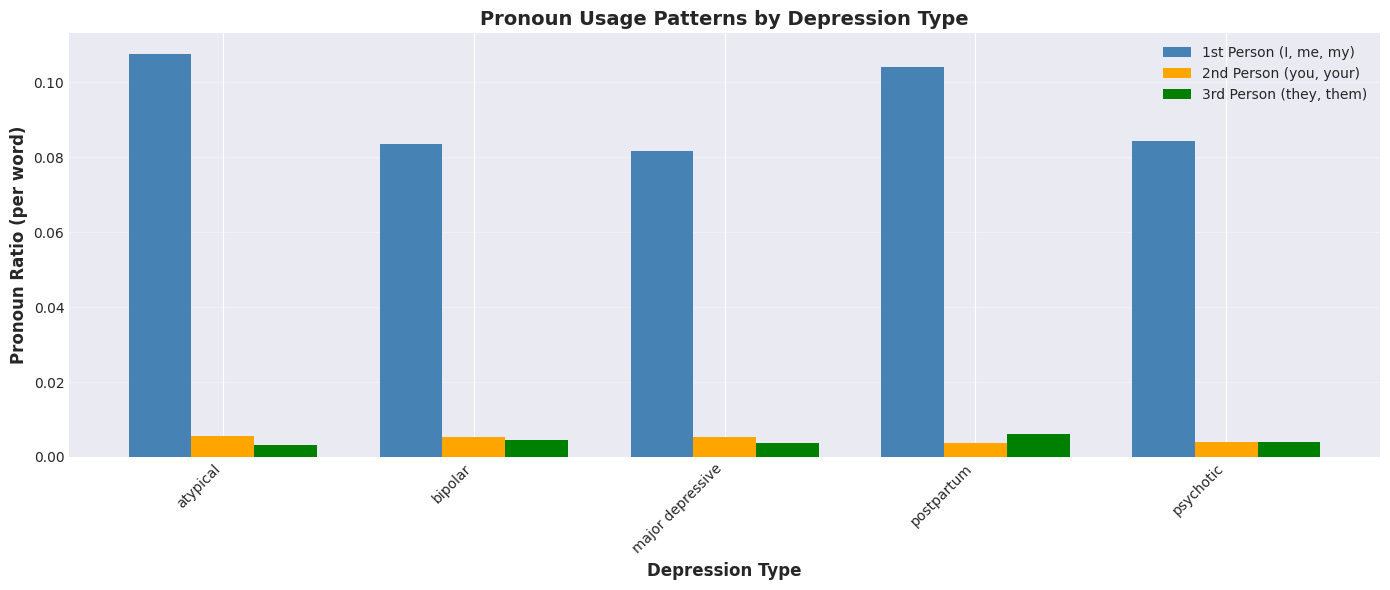

In [17]:
"""
1.12: PRONOUN USAGE PATTERNS - DEPRESSION LINGUISTIC MARKERS
"""
# First-person pronouns (known depression markers)
first_person = ['i', 'me', 'my', 'mine', 'myself']
second_person = ['you', 'your', 'yours', 'yourself']
third_person = ['he', 'she', 'they', 'him', 'her', 'them', 'his', 'hers', 'their']

def count_pronouns(text, pronoun_list):
    #Count pronouns in text
    words = str(text).lower().split()
    return sum(words.count(pronoun) for pronoun in pronoun_list)

df['first_person_count'] = df['text'].apply(lambda x: count_pronouns(x, first_person))
df['second_person_count'] = df['text'].apply(lambda x: count_pronouns(x, second_person))
df['third_person_count'] = df['text'].apply(lambda x: count_pronouns(x, third_person))

# Normalize by word count
df['first_person_ratio'] = df['first_person_count'] / df['word_count']
df['second_person_ratio'] = df['second_person_count'] / df['word_count']
df['third_person_ratio'] = df['third_person_count'] / df['word_count']

print("\nPronoun Usage Ratios by Depression Type:")
print(f"{'Class':<20} {'1st Person':<15} {'2nd Person':<15} {'3rd Person':<15}")

for label in sorted(df['label'].unique()):
    subset = df[df['label'] == label]
    fp = subset['first_person_ratio'].mean()
    sp = subset['second_person_ratio'].mean()
    tp = subset['third_person_ratio'].mean()
    print(f"{label:<20} {fp:<15.4f} {sp:<15.4f} {tp:<15.4f}")

# Statistical test
fp_groups = [df[df['label'] == label]['first_person_ratio'].values 
             for label in df['label'].unique()]
f_stat, p_value = f_oneway(*fp_groups)

print(f"\nANOVA Test (First-Person Pronoun Usage):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))

labels = sorted(df['label'].unique())
x = np.arange(len(labels))
width = 0.25

fp_means = [df[df['label'] == label]['first_person_ratio'].mean() for label in labels]
sp_means = [df[df['label'] == label]['second_person_ratio'].mean() for label in labels]
tp_means = [df[df['label'] == label]['third_person_ratio'].mean() for label in labels]

ax.bar(x - width, fp_means, width, label='1st Person (I, me, my)', color='steelblue')
ax.bar(x, sp_means, width, label='2nd Person (you, your)', color='orange')
ax.bar(x + width, tp_means, width, label='3rd Person (they, them)', color='green')

ax.set_xlabel('Depression Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Pronoun Ratio (per word)', fontsize=12, fontweight='bold')
ax.set_title('Pronoun Usage Patterns by Depression Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
"""
1.13: NEGATION PATTERNS ANALYSIS
"""
# Negation words
negation_words = ['not', 'no', 'never', 'nothing', 'nobody', 'nowhere', 
                  'neither', 'barely', 'hardly', 'scarcely', "n't", 'cant', 'wont', 'dont']

def count_negations(text):
    #Count negation words in text
    words = str(text).lower().split()
    return sum(words.count(neg) for neg in negation_words)

df['negation_count'] = df['text'].apply(count_negations)
df['negation_ratio'] = df['negation_count'] / df['word_count']

print("\nNegation Usage by Depression Type:")
print(f"{'Class':<20} {'Mean Count':<15} {'Mean Ratio':<15} {'Median Ratio':<15}")

for label in sorted(df['label'].unique()):
    subset = df[df['label'] == label]
    mean_count = subset['negation_count'].mean()
    mean_ratio = subset['negation_ratio'].mean()
    median_ratio = subset['negation_ratio'].median()
    print(f"{label:<20} {mean_count:<15.2f} {mean_ratio:<15.4f} {median_ratio:<15.4f}")

# Statistical test
neg_groups = [df[df['label'] == label]['negation_ratio'].values 
              for label in df['label'].unique()]
f_stat, p_value = f_oneway(*neg_groups)

print(f"\nANOVA Test (Negation Usage):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: SIGNIFICANT difference in negation usage")

# Visualization
plt.figure(figsize=(12, 6))
df.boxplot(column='negation_ratio', by='label')
plt.title('Negation Ratio by Depression Type', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Depression Type', fontsize=12)
plt.ylabel('Negation Ratio (per word)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Negation Usage by Depression Type:
Class                Mean Count      Mean Ratio      Median Ratio   
atypical             0.34            0.0106          0.0000         
bipolar              0.54            0.0175          0.0000         
major depressive     0.43            0.0124          0.0000         
postpartum           0.43            0.0132          0.0000         
psychotic            0.42            0.0124          0.0000         

ANOVA Test (Negation Usage):
F-statistic: 32.8307
P-value: 2.7950e-27
Result: SIGNIFICANT difference in negation usage


<Figure size 1200x600 with 0 Axes>


Correlation Matrix:
                     word_count  char_count  sentiment  first_person_ratio  \
word_count                1.000       0.960      0.070              -0.191   
char_count                0.960       1.000      0.061              -0.250   
sentiment                 0.070       0.061      1.000               0.037   
first_person_ratio       -0.191      -0.250      0.037               1.000   
second_person_ratio       0.052       0.080      0.020              -0.134   
third_person_ratio        0.114       0.112      0.012              -0.068   
negation_ratio            0.025       0.002     -0.028              -0.097   

                     second_person_ratio  third_person_ratio  negation_ratio  
word_count                         0.052               0.114           0.025  
char_count                         0.080               0.112           0.002  
sentiment                          0.020               0.012          -0.028  
first_person_ratio                -0.1

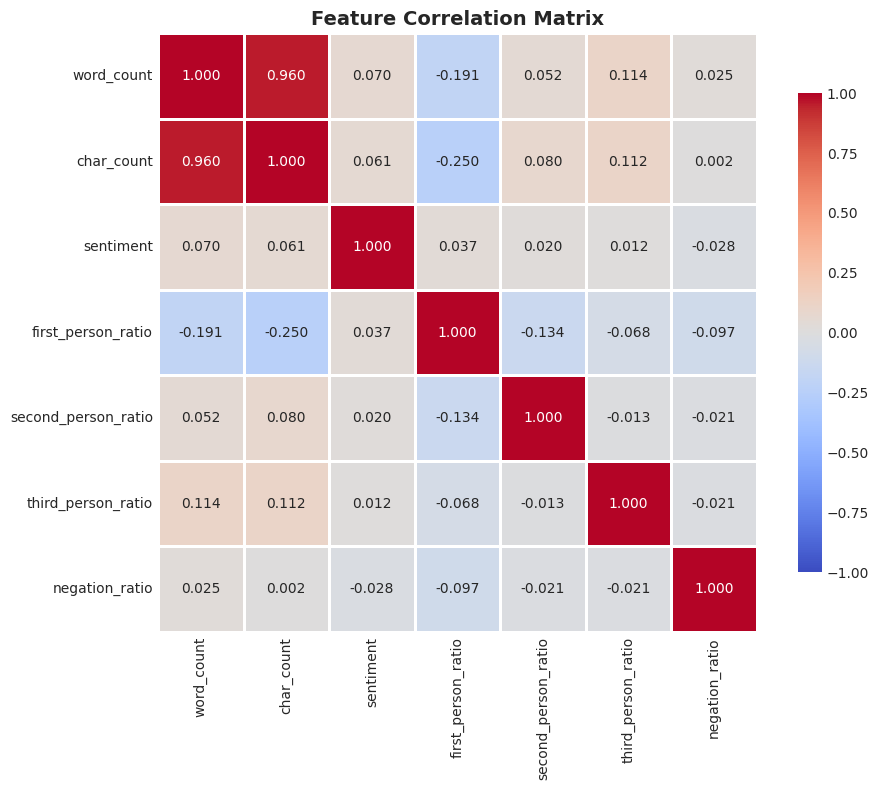

In [19]:
"""
1.14: FEATURE CORRELATION ANALYSIS
"""
# Create correlation matrix of extracted features
feature_cols = ['word_count', 'char_count', 'sentiment', 
                'first_person_ratio', 'second_person_ratio', 'third_person_ratio',
                'negation_ratio']

corr_matrix = df[feature_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
"""
1.15: ADVANCED CLASS SEPARABILITY METRICS
"""
# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=1000, min_df=2)
X_tfidf = tfidf.fit_transform(df['text'])

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

# Calculate separability metrics
silhouette = silhouette_score(X_tfidf, y_encoded, metric='cosine', sample_size=5000)

print("\nClass Separability Metrics (TF-IDF Features):")
print(f"Silhouette Score:{silhouette:.4f}")
print(f"Range: [-1, 1], Higher is better")
print(f"< 0.25: Poor separation, 0.25-0.5: Weak, 0.5-0.7: Reasonable, > 0.7: Strong")
print()
print("\nINTERPRETATION:")
print(f"Silhouette score of {silhouette:.3f} indicates: ", end="")
if silhouette < 0.25:
    print("POOR class separability with TF-IDF")
    print("This STRONGLY justifies using deep learning")
elif silhouette < 0.5:
    print("WEAK class separability with TF-IDF")
    print("This justifies using deep learning for better discrimination.")
else:
    print("REASONABLE class separability")
    print("Deep learning may still improve through semantic understanding.")


Class Separability Metrics (TF-IDF Features):
Silhouette Score:0.0190
Range: [-1, 1], Higher is better
< 0.25: Poor separation, 0.25-0.5: Weak, 0.5-0.7: Reasonable, > 0.7: Strong


INTERPRETATION:
Silhouette score of 0.019 indicates: POOR class separability with TF-IDF
This STRONGLY justifies using deep learning


In [21]:
"""
1.16: SAVE CLEANED DATASET
"""
# Save cleaned dataset for modeling
df.to_csv('dataset_cleaned.csv', index=False)

print(f"\nCleaned dataset saved: dataset_cleaned.csv")


Cleaned dataset saved: dataset_cleaned.csv


Preprocessing

In [22]:
"""
2.1: LOAD CLEANED DATASET
"""
# Load cleaned data from EDA
df = pd.read_csv('dataset_cleaned.csv')

print(f"\nDataset loaded: {len(df):,} samples")
print(f"Classes: {sorted(df['label'].unique())}")
print(f"\nClass distribution:")
print(df['label'].value_counts().sort_index())


Dataset loaded: 12,998 samples
Classes: ['atypical', 'bipolar', 'major depressive', 'postpartum', 'psychotic']

Class distribution:
atypical            1980
bipolar             2443
major depressive    2517
postpartum          3746
psychotic           2312
Name: label, dtype: int64


In [23]:
"""
2.3: SOCIAL MEDIA TEXT NORMALIZATION
"""
def normalize_social_media_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # 1. Convert emojis to text (preserve emotional meaning)
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    # 2. Expand contractions (can't -> cannot), Important for transformers to understand negation
    text = contractions.fix(text)
    
    # 3. Normalize URLs to [URL] token, Preserves presence of link without noise
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text, flags=re.MULTILINE)
    
    # 4. Normalize mentions to [USER] token
    text = re.sub(r'@\w+', '[USER]', text)
    
    # 5. Normalize hashtags (remove # but keep word)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # 6. Normalize repeated characters (preserve emphasis), Example: soooo sad -> soo sad (keep double for emphasis)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 8. Lowercase (standard for transformers)
    text = text.lower()
    
    return text

# Show examples before/after
sample_texts = df['text'].head(5).tolist()

for i, original in enumerate(sample_texts, 1):
    normalized = normalize_social_media_text(original)
    print(f"\nExample {i}:")
    print(f"Original:{original[:100]}...")
    print(f"Normalized: {normalized[:100]}...")

# Apply normalization
df['text_normalized'] = df['text'].apply(normalize_social_media_text)

# Check for empty texts after normalization
empty_count = (df['text_normalized'].str.len() == 0).sum()
print(f"\nEmpty texts after normalization: {empty_count}")

if empty_count > 0:
    df = df[df['text_normalized'].str.len() > 0].reset_index(drop=True)

print(f"\nFinal dataset size: {len(df):,} samples")

print("\nNormalization statistics:")
print(f"Original mean length: {df['text'].str.len().mean():.1f} chars")
print(f"Normalized mean length: {df['text_normalized'].str.len().mean():.1f} chars")


Example 1:
Original:I been going thru depression  I didnt even realize it till a couple weeks ago I always said Im stron...
Normalized: i been going thru depression i did not even realize it till a couple weeks ago i always said i am st...

Example 2:
Original:@keshab_mahanta hello Health minister sir,I m a working mother in Irrigation department in Governmen...
Normalized: [user] hello health minister sir,i m a working mother in irrigation department in government of assa...

Example 3:
Original:FYI in case anyone is concerned - I am NOT actually getting drunk. 槀 Im on baby duty today, plus sin...
Normalized: fyi in case anyone is concerned - i am not actually getting drunk. 槀 i am on baby duty today, plus s...

Example 4:
Original:@victorr_ugo Thankful I am able to hold my baby now after suffering from  depression for 8 weeks ....
Normalized: [user] thankful i am able to hold my baby now after suffering from depression for 8 weeks ....

Example 5:
Original:I think I might be sufferi

In [24]:
df.head()

,text,label,char_count,word_count,sentiment,first_person_count,second_person_count,third_person_count,first_person_ratio,second_person_ratio,third_person_ratio,negation_count,negation_ratio,text_normalized
0,I been going thru depression I didnt even rea...,postpartum,265,54,0.211111,7,3,0,0.129630,0.055556,0.0,1,0.018519,i been going thru depression i did not even re...
1,"@keshab_mahanta hello Health minister sir,I m ...",postpartum,244,41,-0.202778,4,0,0,0.097561,0.000000,0.0,0,0.000000,"[user] hello health minister sir,i m a working..."
2,FYI in case anyone is concerned - I am NOT act...,postpartum,266,52,-0.033333,6,0,0,0.115385,0.000000,0.0,2,0.038462,fyi in case anyone is concerned - i am not act...
3,@victorr_ugo Thankful I am able to hold my bab...,postpartum,98,18,0.500000,2,0,0,0.111111,0.000000,0.0,0,0.000000,[user] thankful i am able to hold my baby now ...
4,I think I might be suffering from depression ...,postpartum,63,11,-0.100000,2,0,0,0.181818,0.000000,0.0,0,0.000000,i think i might be suffering from depression m...


In [25]:
df.columns

Index(['text', 'label', 'char_count', 'word_count', 'sentiment',
       'first_person_count', 'second_person_count', 'third_person_count',
       'first_person_ratio', 'second_person_ratio', 'third_person_ratio',
       'negation_count', 'negation_ratio', 'text_normalized'],
      dtype='object')


Total samples: 12,998
Classes: ['atypical', 'bipolar', 'major depressive', 'postpartum', 'psychotic']

Split sizes:
Train: 9,098 (70.0%)
Val:   1,950 (15.0%)
Test:  1,950 (15.0%)

Class distribution across splits:
Class                Train           Val             Test            Total          
atypical             15.23% (1386) 15.23% ( 297) 15.23% ( 297) 15.23% (1980)
bipolar              18.80% (1710) 18.77% ( 366) 18.82% ( 367) 18.80% (2443)
major depressive     19.37% (1762) 19.38% ( 378) 19.33% ( 377) 19.36% (2517)
postpartum           28.82% (2622) 28.82% ( 562) 28.82% ( 562) 28.82% (3746)
psychotic            17.78% (1618) 17.79% ( 347) 17.79% ( 347) 17.79% (2312)


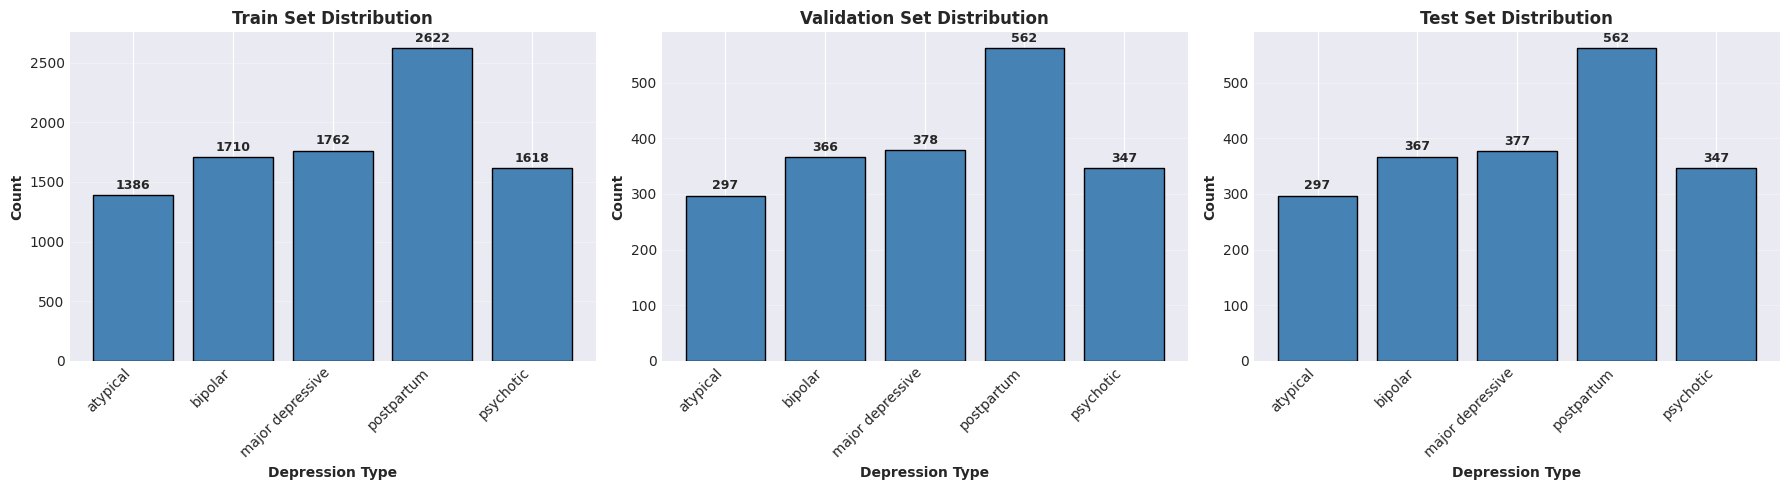

In [26]:
"""
2.4: STRATIFIED TRAIN/VAL/TEST SPLIT
"""
# Extract features and labels
X = df['text_normalized'].to_numpy()  
y = df['label'].to_numpy()            

print(f"\nTotal samples: {len(X):,}")
print(f"Classes: {sorted(np.unique(y))}")

# First split: 70% train, 30% temp (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

# Second split: 50/50 of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("\nSplit sizes:")
print(f"Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
train_dist = Counter(y_train)
val_dist = Counter(y_val)
test_dist = Counter(y_test)
total_dist = Counter(y)

print("\nClass distribution across splits:")
print(f"{'Class':<20} {'Train':<15} {'Val':<15} {'Test':<15} {'Total':<15}")

for label in sorted(np.unique(y)):
    train_pct = train_dist[label] / len(y_train) * 100
    val_pct = val_dist[label] / len(y_val) * 100
    test_pct = test_dist[label] / len(y_test) * 100
    total_pct = total_dist[label] / len(y) * 100
    
    print(f"{label:<20} {train_pct:>5.2f}% ({train_dist[label]:>4}) "
          f"{val_pct:>5.2f}% ({val_dist[label]:>4}) "
          f"{test_pct:>5.2f}% ({test_dist[label]:>4}) "
          f"{total_pct:>5.2f}% ({total_dist[label]:>4})")

# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ('Train', y_train, axes[0]),
    ('Validation', y_val, axes[1]),
    ('Test', y_test, axes[2])
]

for split_name, split_data, ax in splits:
    split_counts = pd.Series(split_data).value_counts().sort_index()
    
    ax.bar(range(len(split_counts)), split_counts.values, color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(split_counts)))
    ax.set_xticklabels(split_counts.index, rotation=45, ha='right')
    ax.set_xlabel('Depression Type', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'{split_name} Set Distribution', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Add counts on bars
    for i, count in enumerate(split_counts.values):
        ax.text(i, count + max(split_counts)*0.01, str(count), 
               ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
"""
2.5: CLASS IMBALANCE HANDLING - COMPUTE CLASS WEIGHTS
"""
# Compute class weights
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    'balanced',
    classes=classes,
    y=y_train
)

# Create dictionary mapping
class_weights_dict = {label: weight for label, weight in zip(classes, class_weights_array)}

print("\nClass Weights (Balanced):")
for label in sorted(class_weights_dict.keys()):
    weight = class_weights_dict[label]
    count = train_dist[label]
    print(f"{label:<20} Weight: {weight:.4f}  (n={count})")

# Convert to PyTorch tensor for later use
label_to_idx = {label: idx for idx, label in enumerate(sorted(classes))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

# Create weight tensor ordered by class index
class_weights_tensor = torch.tensor(
    [class_weights_dict[idx_to_label[i]] for i in range(len(classes))],
    dtype=torch.float
)

print(f"\nClass weights tensor: {class_weights_tensor}")

# Visualize weights
plt.figure(figsize=(10, 6))
labels_sorted = sorted(class_weights_dict.keys())
weights = [class_weights_dict[label] for label in labels_sorted]
counts = [train_dist[label] for label in labels_sorted]

x = np.arange(len(labels_sorted))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x - width/2, counts, width, label='Sample Count', color='steelblue', alpha=0.7)
ax1.set_xlabel('Depression Type', fontweight='bold', fontsize=12)
ax1.set_ylabel('Sample Count', fontweight='bold', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_sorted, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.bar(x + width/2, weights, width, label='Class Weight', color='coral', alpha=0.7)
ax2.set_ylabel('Class Weight', fontweight='bold', fontsize=12, color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Class Counts vs Computed Weights', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Class Weights (Balanced):
atypical             Weight: 1.3128  (n=1386)
bipolar              Weight: 1.0641  (n=1710)
major depressive     Weight: 1.0327  (n=1762)
postpartum           Weight: 0.6940  (n=2622)
psychotic            Weight: 1.1246  (n=1618)

Class weights tensor: tensor([1.3128, 1.0641, 1.0327, 0.6940, 1.1246])


<Figure size 1000x600 with 0 Axes>

In [ ]:
"""
2.6: HUGGING FACE AUTHENTICATION
"""
# Token pasted from hugging face
login(token="YOUR_HUGGING_FACE_TOKEN_HERE")  # Replace with your actual token
print("Successfully logged in to Hugging Face")

Successfully logged in to Hugging Face



Loaded tokenizers:
 - MentalBERT
 - Twitter-RoBERTa

Sample text: it is hard to admit, but some days i feel like i am drowning. my baby is crying and i cannot seem to...

MentalBERT Tokenization:
Tokens (first 15): ['it', 'is', 'hard', 'to', 'admit', ',', 'but', 'some', 'days', 'i', 'feel', 'like', 'i', 'am', 'drowning']
Token IDs (first 15): [101, 2009, 2003, 2524, 2000, 6449, 1010, 2021, 2070, 2420, 1045, 2514, 2066, 1045, 2572]
Total tokens: 45
Vocab size: 30,522

Twitter-RoBERTa Tokenization:
Tokens (first 15): ['it', 'Ġis', 'Ġhard', 'Ġto', 'Ġadmit', ',', 'Ġbut', 'Ġsome', 'Ġdays', 'Ġi', 'Ġfeel', 'Ġlike', 'Ġi', 'Ġam', 'Ġdrowning']
Token IDs (first 15): [0, 405, 16, 543, 7, 8109, 6, 53, 103, 360, 939, 619, 101, 939, 524]
Total tokens: 46
Vocab size: 50,265

Sequence length statistics (sample of 1000):
Mean: 42.8
Median: 42.0
95th percentile: 67.0
Max: 94


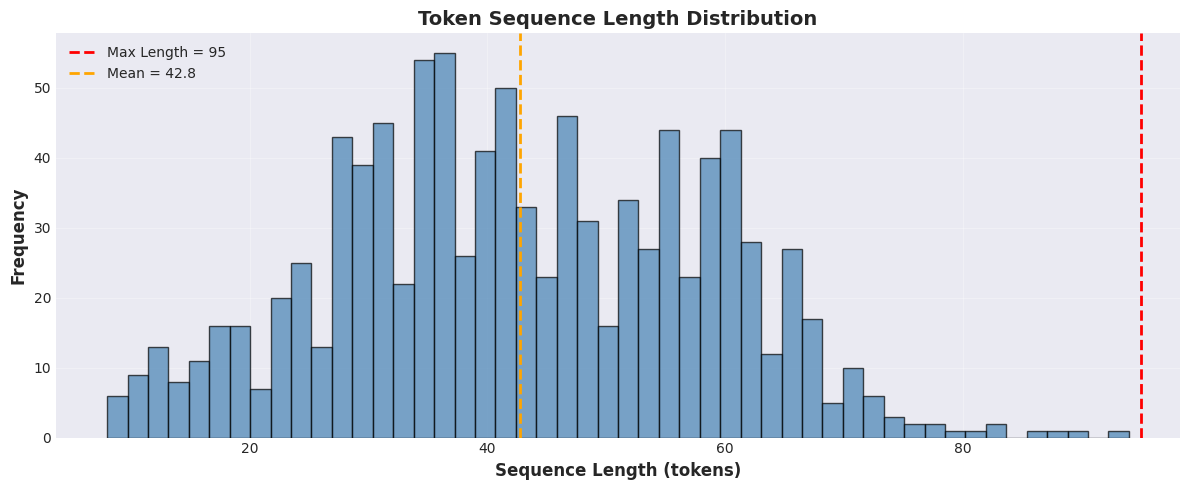

In [29]:
"""
2.7: TOKENIZATION PREVIEW (All Models)
"""
# Load tokenizers 
tokenizers = {
    'MentalBERT': AutoTokenizer.from_pretrained('mental/mental-bert-base-uncased'),
    'Twitter-RoBERTa': AutoTokenizer.from_pretrained('cardiffnlp/twitter-roberta-base-sentiment-latest')
}

print("\nLoaded tokenizers:")
for name in tokenizers.keys():
    print(f" - {name}")

# Test tokenization on sample text
sample_text = X_train[0]
print(f"\nSample text: {sample_text[:100]}...")

for model_name, tokenizer in tokenizers.items():
    print(f"\n{model_name} Tokenization:")
    
    # Tokenize
    tokens = tokenizer.tokenize(sample_text)
    token_ids = tokenizer.encode(sample_text, add_special_tokens=True)
    
    print(f"Tokens (first 15): {tokens[:15]}")
    print(f"Token IDs (first 15): {token_ids[:15]}")
    print(f"Total tokens: {len(token_ids)}")
    print(f"Vocab size: {tokenizer.vocab_size:,}")

# Check sequence length distribution
# Use MentalBERT tokenizer for analysis
tokenizer = tokenizers['MentalBERT']

train_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in X_train[:1000]]

print(f"\nSequence length statistics (sample of 1000):")
print(f"Mean: {np.mean(train_lengths):.1f}")
print(f"Median: {np.median(train_lengths):.1f}")
print(f"95th percentile: {np.percentile(train_lengths, 95):.1f}")
print(f"Max: {np.max(train_lengths)}")

# Visualize
plt.figure(figsize=(12, 5))
plt.hist(train_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(95, color='red', linestyle='--', linewidth=2, label='Max Length = 95')
plt.axvline(np.mean(train_lengths), color='orange', linestyle='--', linewidth=2, 
           label=f'Mean = {np.mean(train_lengths):.1f}')
plt.xlabel('Sequence Length (tokens)', fontweight='bold', fontsize=12)
plt.ylabel('Frequency', fontweight='bold', fontsize=12)
plt.title('Token Sequence Length Distribution', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Determine max_length
max_length_95 = int(np.percentile(train_lengths, 95))
max_length_chosen = 95  # Standard BERT max

print(f"\nMAX_LENGTH DECISION:")
print(f"95th percentile: {max_length_95}")
print(f"Chosen max_length: {max_length_chosen}")
print(f"Reason: Covers {(np.array(train_lengths) <= max_length_chosen).mean()*100:.1f}% of sequences")


MAX_LENGTH DECISION:
95th percentile: 67
Chosen max_length: 95
Reason: Covers 100.0% of sequences


# PART 2: BASELINE ML MODEL (TF-IDF + SVM)

ML Model Analysis

In [31]:
"""
3.2: CREATE TF-IDF FEATURES
"""
# TF-IDF Vectorizer with optimal settings for text classification
tfidf = TfidfVectorizer(
    max_features=5000,        # Top 5000 features (balance between coverage and sparsity)
    ngram_range=(1, 2),       # Unigrams and bigrams (captures some context)
    min_df=2,                 # Minimum document frequency (remove very rare words)
    max_df=0.95,              # Maximum document frequency (remove very common words)
    sublinear_tf=True,        # Use log scaling for term frequencies
    strip_accents='unicode',  # Normalize accents
    lowercase=True,           # Already done in preprocessing, but ensure consistency
    stop_words='english'      # Remove common English stop words
)

print("\nTF-IDF Configuration:")
print(f"Max features:{tfidf.max_features:,}")
print(f"N-gram range:{tfidf.ngram_range}")
print(f"Min doc frequency:{tfidf.min_df}")
print(f"Max doc frequency:{tfidf.max_df}")
print(f"Sublinear TF:{tfidf.sublinear_tf}")

# Fit on training data and transform all splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Feature Matrix:")
print(f"Max features:{X_train_tfidf.shape[0]}")
print(f"Val shape:{X_val_tfidf.shape}")
print(f"Test shape:{X_test_tfidf.shape}")
print(f"Vocabulary size:{len(tfidf.vocabulary_):,}")
print(f"Sparsity:{(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")


TF-IDF Configuration:
Max features:5,000
N-gram range:(1, 2)
Min doc frequency:2
Max doc frequency:0.95
Sublinear TF:True

TF-IDF Feature Matrix:
Max features:9098
Val shape:(1950, 5000)
Test shape:(1950, 5000)
Vocabulary size:5,000
Sparsity:99.67%


In [32]:
"""
3.3: BASELINE Model - TF-IDF + SVM
"""
#Train SVM with linear kernel (good for high-dimensional sparse data)
svm_model = SVC(
    kernel='linear',          # Linear kernel works well for high-dimensional text
    class_weight='balanced',  # Automatically adjust weights inversely to class frequencies
    random_state=SEED,
    verbose=False
)

svm_model.fit(X_train_tfidf, y_train)
print("\nTraining complete")

# Predictions
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_val_pred_svm = svm_model.predict(X_val_tfidf)



Training complete



TF-IDF + SVM Metrics:
Accuracy:0.9051 (90.51%)
F1-Macro:0.9067 (90.67%)
F1-Weighted:0.9057 (90.57%)
Precision:0.9077
Recall:0.9068

Per-Class F1 Scores:
atypical             0.9966 (99.66%)
bipolar              0.9205 (92.05%)
major depressive     0.8279 (82.79%)
postpartum           0.9286 (92.86%)
psychotic            0.8599 (85.99%)

Detailed Classification Report:
                  precision    recall  f1-score   support

        atypical     0.9966    0.9966    0.9966       297
         bipolar     0.9586    0.8852    0.9205       366
major depressive     0.8225    0.8333    0.8279       378
      postpartum     0.9319    0.9253    0.9286       562
       psychotic     0.8289    0.8934    0.8599       347

        accuracy                         0.9051      1950
       macro avg     0.9077    0.9068    0.9067      1950
    weighted avg     0.9072    0.9051    0.9057      1950


Train F1-Macro:0.9676
Val F1-Macro:0.9067
Gap:0.0610
Some overfitting detected (train >> val).


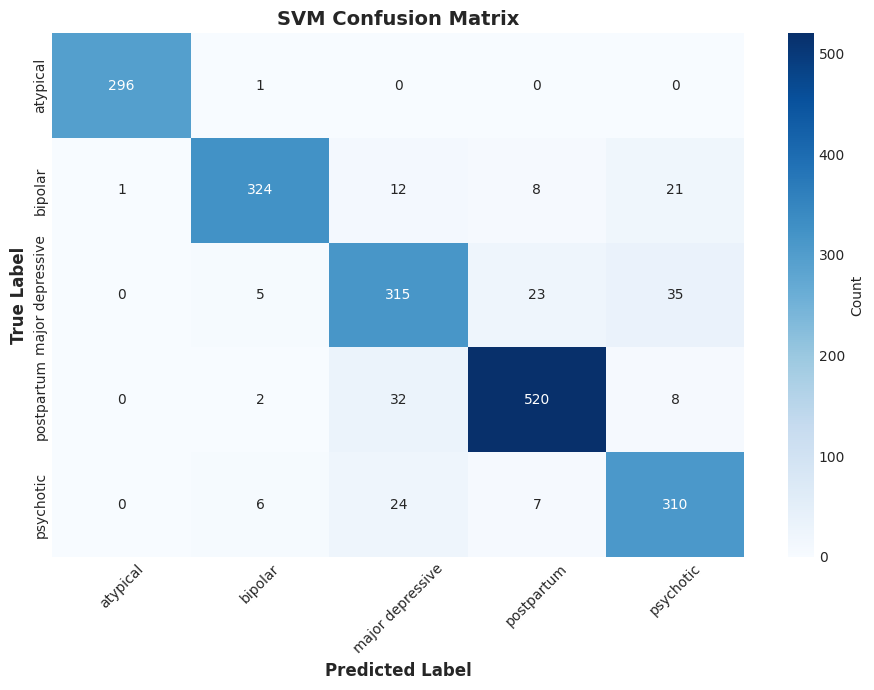


Most Common Misclassifications:
            True        Predicted  Count
major depressive        psychotic     35
      postpartum major depressive     32
       psychotic major depressive     24
major depressive       postpartum     23
         bipolar        psychotic     21
         bipolar major depressive     12
         bipolar       postpartum      8
      postpartum        psychotic      8
       psychotic       postpartum      7
       psychotic          bipolar      6


In [33]:
"""
3.4: TF-IDF + SVM EVALUATION
"""
# Evaluation on validation set
svm_accuracy = accuracy_score(y_val, y_val_pred_svm)
svm_f1_macro = f1_score(y_val, y_val_pred_svm, average='macro')
svm_f1_weighted = f1_score(y_val, y_val_pred_svm, average='weighted')
svm_precision = precision_score(y_val, y_val_pred_svm, average='macro')
svm_recall = recall_score(y_val, y_val_pred_svm, average='macro')

print(f"\nTF-IDF + SVM Metrics:")
print(f"Accuracy:{svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"F1-Macro:{svm_f1_macro:.4f} ({svm_f1_macro*100:.2f}%)")
print(f"F1-Weighted:{svm_f1_weighted:.4f} ({svm_f1_weighted*100:.2f}%)")
print(f"Precision:{svm_precision:.4f}")
print(f"Recall:{svm_recall:.4f}")

# Per-class F1 scores
print("\nPer-Class F1 Scores:")
svm_f1_per_class = f1_score(y_val, y_val_pred_svm, average=None)
for label, f1 in zip(sorted(label_to_idx.keys()), svm_f1_per_class):
    print(f"{label:<20} {f1:.4f} ({f1*100:.2f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_val, y_val_pred_svm, 
                          target_names=sorted(label_to_idx.keys()),
                          digits=4))

# Training set performance (check for overfitting)
svm_train_f1 = f1_score(y_train, y_train_pred_svm, average='macro')
print(f"\nTrain F1-Macro:{svm_train_f1:.4f}")
print(f"Val F1-Macro:{svm_f1_macro:.4f}")
print(f"Gap:{abs(svm_train_f1 - svm_f1_macro):.4f}")

if abs(svm_train_f1 - svm_f1_macro) < 0.05:
    print("No significant overfitting detected.")
else:
    print("Some overfitting detected (train >> val).")

# Confusion matrix
cm_svm=confusion_matrix(y_val, y_val_pred_svm, labels=sorted(label_to_idx.keys()))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(label_to_idx.keys()),
            yticklabels=sorted(label_to_idx.keys()),
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('SVM Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Remove the empty axis
fig.delaxes(axes[1])

plt.tight_layout()
plt.show()

# Analyse confusion patterns
print("\nMost Common Misclassifications:")
classes = sorted(label_to_idx.keys())
misclass_counts = []

# Identify the most common misclassifications
for i, true_label in enumerate(classes):
    for j, pred_label in enumerate(classes):
        if i != j and cm_svm[i][j] > 0:
            misclass_counts.append({
                'True': true_label,
                'Predicted': pred_label,
                'Count': cm_svm[i][j]
            })

misclass_df = pd.DataFrame(misclass_counts).sort_values('Count', ascending=False)
print(misclass_df.head(10).to_string(index=False))

# PART 3: MENTALBERT FINE-TUNING

In [34]:
"""
4.2: MENTALBERT MODEL SETUP
"""
MODEL_NAME = "mental/mental-bert-base-uncased"
MAX_LENGTH = 95
NUM_LABELS = len(label_to_idx)

print(f"\nModel: {MODEL_NAME}")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Number of labels: {NUM_LABELS}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification"
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model loaded: mental/mental-bert-base-uncased
Total parameters: 109,486,085
Trainable parameters: 109,486,085


In [35]:
"""
4.3: TOKENIZE DATA
"""
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Convert string labels to integer indices
y_train_idx = [label_to_idx[label] for label in y_train]
y_val_idx   = [label_to_idx[label] for label in y_val]
y_test_idx  = [label_to_idx[label] for label in y_test]

# Create datasets
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train_idx})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val_idx})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test_idx})

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("\nTokenization complete")
print(f"Train:{len(train_dataset):,} samples")
print(f"Val:{len(val_dataset):,} samples")
print(f"Test:{len(test_dataset):,} samples")

Map:  51%|█████▏    | 1000/1950 [00:00<00:00, 6794.00 examples/s]


In [36]:
"""
4.4: CUSTOM TRAINER WITH CLASS WEIGHTS
"""
class WeightedTrainer(Trainer):
    """
    Custom Trainer that uses class-weighted CrossEntropyLoss.
    
    This addresses class imbalance by penalizing mistakes on minority classes more heavily.
    """
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Use class-weighted CrossEntropyLoss
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

In [37]:
"""
4.5: METRICS DEFINITION
"""
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics.
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'precision': precision_score(labels, predictions, average='macro'),
        'recall': recall_score(labels, predictions, average='macro')
    }

In [38]:
"""
4.6.1: TRAINING CONFIGURATION
"""
# Hyperparameters
LEARNING_RATE = 2e-5  # Standard BERT fine-tuning rate (Devlin et al., 2019)
BATCH_SIZE = 16       # Balanced trade-off: memory vs convergence
NUM_EPOCHS = 10       
WARMUP_STEPS = 100    # Gradual learning rate increase (10% of training steps)
WEIGHT_DECAY = 0.01   # L2 regularization (prevents overfitting)

# Training arguments
training_args = TrainingArguments(
    output_dir='./mentalbert_checkpoints',
    num_train_epochs=1,  # Trained with 20 epochs for submission
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    
    # Evaluation strategy
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='no',
    
    # Logging
    logging_dir='./mentalbert_logs',
    logging_steps=50,
    
    # Best model selection
    load_best_model_at_end=False,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    
    # Performance
    fp16=torch.cuda.is_available(),  # Mixed precision if GPU available
    dataloader_num_workers=4,
    
    # Reproducibility
    seed=SEED,
    
    # Misc
    report_to='none',  # Disable wandb/tensorboard
    save_total_limit=3  # Keep only 3 best checkpoints
)

print("\nTraining arguments configured.")


Training arguments configured.


In [39]:
"""
4.6: COMPUTE CLASS WEIGHTS
"""
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# Create and fit label encoder
label_encoder = LabelEncoder()
label_encoder.fit(df['label'])  # Fit on all labels

# Encode the training labels
y_train_encoded = label_encoder.transform(y_train)

# Get unique labels
unique_labels = np.unique(y_train_encoded)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=y_train_encoded
)

# Convert to tensor
class_weights = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("Class Weights (Balanced):")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label:20s} Weight: {class_weights[i]:.4f}  (n={sum(y_train_encoded == i)})")
    
print(f"\nClass weights tensor: {class_weights}")

Class Weights (Balanced):
atypical             Weight: 1.3128  (n=1386)
bipolar              Weight: 1.0641  (n=1710)
major depressive     Weight: 1.0327  (n=1762)
postpartum           Weight: 0.6940  (n=2622)
psychotic            Weight: 1.1246  (n=1618)

Class weights tensor: tensor([1.3128, 1.0641, 1.0327, 0.6940, 1.1246], device='cuda:0')


In [40]:
"""
4.7: INITIALIZE TRAINER
"""
# Initialize custom trainer with class weights
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[]
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] used in original training
)

In [41]:
"""
4.8: TRAIN MODEL
"""
# Train
train_result = trainer.train()
print("TRAINING COMPLETE") 

# Training metrics
print("\nTraining Metrics:")
print(f"Total training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")



Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
100,1.038600,0.533466,0.826667,0.831831,0.833132,0.849796,0.833719
200,0.317800,0.278785,0.899487,0.898960,0.899227,0.901646,0.898798
300,0.233300,0.241519,0.901538,0.904567,0.902511,0.903028,0.907819
400,0.178100,0.228476,0.920000,0.920332,0.919709,0.920105,0.920825
500,0.265400,0.218984,0.911282,0.914756,0.912905,0.914789,0.916972


TRAINING COMPLETE

Training Metrics:
Total training time: 63.46 seconds
Training loss: 0.4487
Training samples/second: 143.37


In [42]:
"""
4.9: EVALUATION ON VALIDATION SET
"""

# Evaluate
eval_results = trainer.evaluate()

print("\nValidation Results:")
print(f"Accuracy:{eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1-Macro:{eval_results['eval_f1_macro']:.4f} ({eval_results['eval_f1_macro']*100:.2f}%)")
print(f"F1-Weighted:{eval_results['eval_f1_weighted']:.4f} ({eval_results['eval_f1_weighted']*100:.2f}%)")
print(f"Precision:{eval_results['eval_precision']:.4f}")
print(f"Recall:{eval_results['eval_recall']:.4f}")
print(f"Loss:{eval_results['eval_loss']:.4f}")

# Get predictions for detailed analysis
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Per-class F1 scores
print("\nPer-Class F1 Scores:")
f1_per_class = f1_score(y_true, y_pred, average=None)
for idx, (label, f1) in enumerate(zip(sorted(label_to_idx.keys()), f1_per_class)):
    print(f"{label:<20} {f1:.4f} ({f1*100:.2f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=sorted(label_to_idx.keys()),
                          digits=4))


Validation Results:
Accuracy:0.9210 (92.10%)
F1-Macro:0.9220 (92.20%)
F1-Weighted:0.9213 (92.13%)
Precision:0.9211
Recall:0.9232
Loss:0.2087

Per-Class F1 Scores:
atypical             0.9933 (99.33%)
bipolar              0.9547 (95.47%)
major depressive     0.8439 (84.39%)
postpartum           0.9405 (94.05%)
psychotic            0.8776 (87.76%)

Detailed Classification Report:
                  precision    recall  f1-score   support

        atypical     0.9933    0.9933    0.9933       297
         bipolar     0.9587    0.9508    0.9547       366
major depressive     0.8439    0.8439    0.8439       378
      postpartum     0.9526    0.9288    0.9405       562
       psychotic     0.8571    0.8991    0.8776       347

        accuracy                         0.9210      1950
       macro avg     0.9211    0.9232    0.9220      1950
    weighted avg     0.9219    0.9210    0.9213      1950



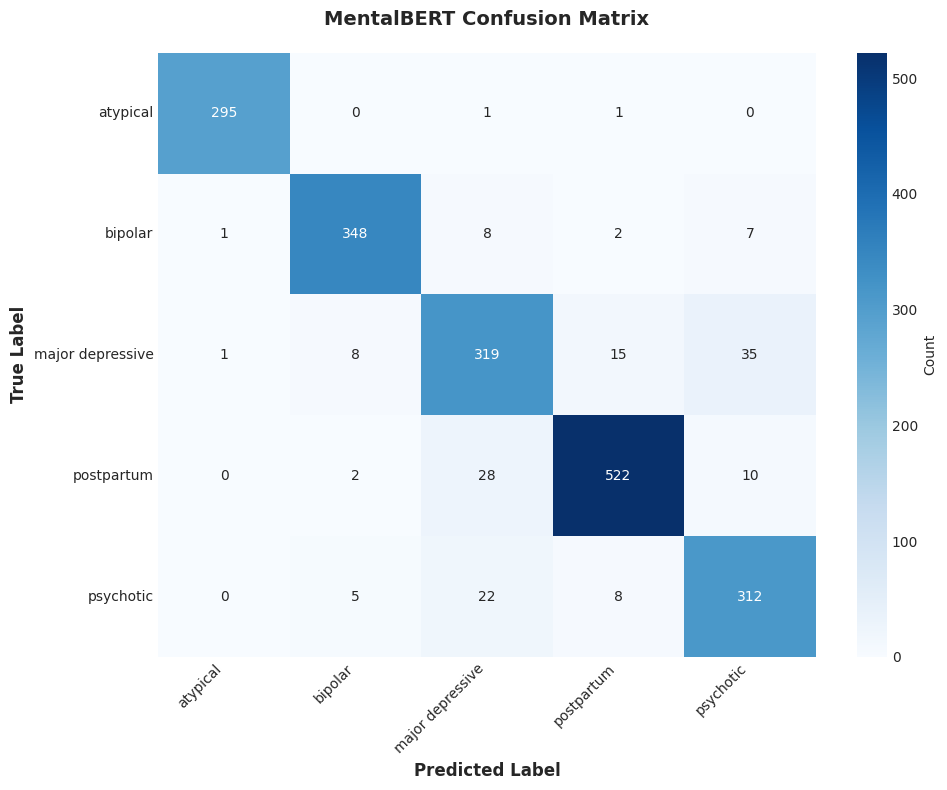


Confusion Matrix Analysis:
   atypical              295/ 297 correct (99.3%)
   bipolar               348/ 366 correct (95.1%)
   major depressive      319/ 378 correct (84.4%)
   postpartum            522/ 562 correct (92.9%)
   psychotic             312/ 347 correct (89.9%)


In [43]:
"""
4.10: CONFUSION MATRIX
"""
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(label_to_idx.keys()),
            yticklabels=sorted(label_to_idx.keys()),
            cbar_kws={'label': 'Count'})
plt.title('MentalBERT Confusion Matrix', fontweight='bold', fontsize=14, pad=20)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analysis
print("\nConfusion Matrix Analysis:")
for i, label in enumerate(sorted(label_to_idx.keys())):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total if total > 0 else 0
    print(f"   {label:<20} {correct:4d}/{total:4d} correct ({accuracy*100:.1f}%)")

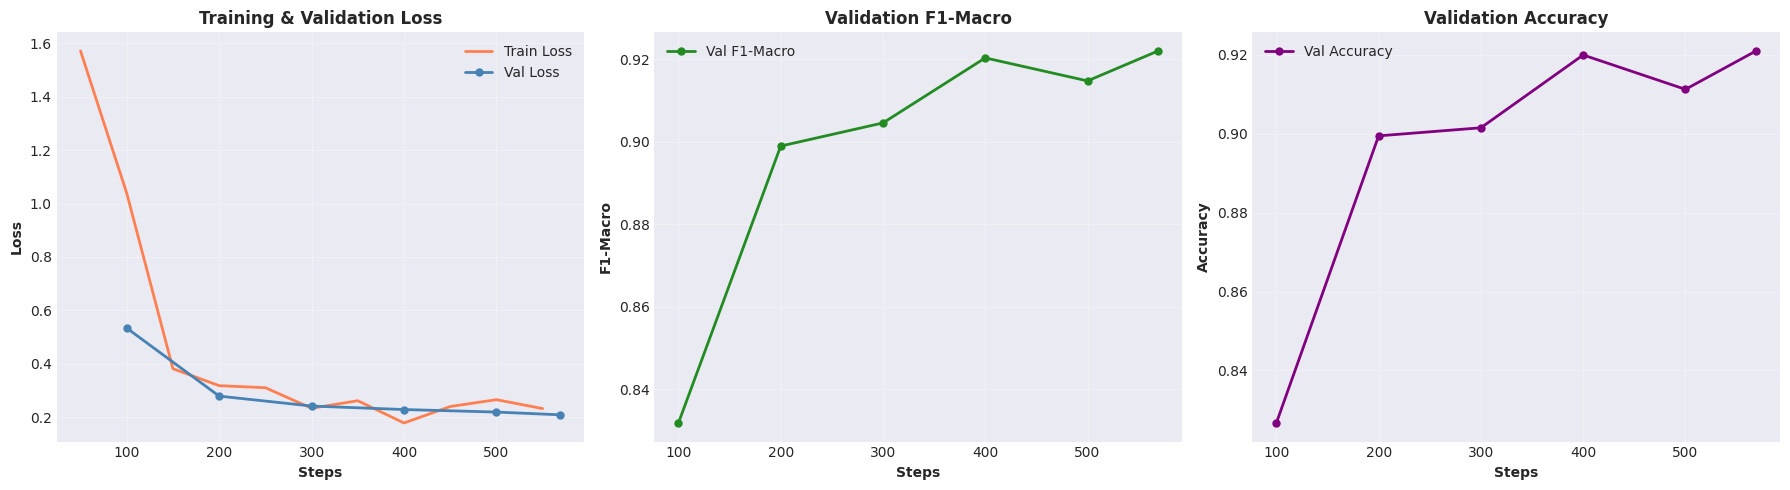


Best validation metrics:
Step: 569
F1-Macro: 0.9220
Accuracy: 0.9210
Loss: 0.2087


In [44]:
"""
4.11: TRAINING CURVES
"""
# Extract training history
log_history = trainer.state.log_history

# Parse logs
train_loss = []
train_steps = []
eval_loss = []
eval_f1 = []
eval_acc = []
eval_steps = []

for entry in log_history:
    if 'loss' in entry:
        train_loss.append(entry['loss'])
        train_steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_f1.append(entry['eval_f1_macro'])
        eval_acc.append(entry['eval_accuracy'])
        eval_steps.append(entry['step'])

# Plot
if eval_loss:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(train_steps, train_loss, label='Train Loss', color='coral', linewidth=2)
    axes[0].plot(eval_steps, eval_loss, label='Val Loss', color='steelblue', linewidth=2, marker='o', markersize=5)
    axes[0].set_xlabel('Steps', fontweight='bold')
    axes[0].set_ylabel('Loss', fontweight='bold')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # F1-Macro
    axes[1].plot(eval_steps, eval_f1, label='Val F1-Macro', color='forestgreen', linewidth=2, marker='o', markersize=5)
    axes[1].set_xlabel('Steps', fontweight='bold')
    axes[1].set_ylabel('F1-Macro', fontweight='bold')
    axes[1].set_title('Validation F1-Macro', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Accuracy
    axes[2].plot(eval_steps, eval_acc, label='Val Accuracy', color='purple', linewidth=2, marker='o', markersize=5)
    axes[2].set_xlabel('Steps', fontweight='bold')
    axes[2].set_ylabel('Accuracy', fontweight='bold')
    axes[2].set_title('Validation Accuracy', fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    #plt.savefig('mentalbert_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Best metrics
    print("\nBest validation metrics:")
    best_idx = np.argmax(eval_f1)
    print(f"Step: {eval_steps[best_idx]}")
    print(f"F1-Macro: {eval_f1[best_idx]:.4f}")
    print(f"Accuracy: {eval_acc[best_idx]:.4f}")
    print(f"Loss: {eval_loss[best_idx]:.4f}")
else:
    print("\nNo evaluation logs found. Training may have been too short.")

In [45]:
"""
HYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT
Training for 20 epochs, these parameters were obtained for MENTALBERT:
  - learning_rate: 2.461834502428895e-05
  - batch_size: 8
  - weight_decay: 0.07869797485122046
  - warmup_ratio: 0.12309449718520415
"""

# """
# 5.1: HYPERPARAMETER OPTIMIZATION WITH OPTUNA
# """
# 
# def objective(trial):
#     """
#     Args - trial: Optuna trial object containing hyperparameter suggestions
#     Returns - float: Validation F1-macro score (higher is better)
#     """
#     
#     # Hyperparameter suggestions
#     learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
#     batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
#     weight_decay = trial.suggest_float('weight_decay', 0.0, 0.1)
#     warmup_ratio = trial.suggest_float('warmup_ratio', 0.0, 0.2)
#     
#     # Reload model (fresh weights each trial)
#     model = AutoModelForSequenceClassification.from_pretrained(
#         'mental/mental-bert-base-uncased',
#         num_labels=len(label_to_idx),
#         problem_type='single_label_classification',
#         ignore_mismatched_sizes=True
#     )
#     model.to(device)
#     
#     # Training arguments
#     trial_args = TrainingArguments(
#         output_dir=f'./optuna_trial_{trial.number}',
#         learning_rate=learning_rate,
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         num_train_epochs=10,
#         weight_decay=weight_decay,
#         warmup_ratio=warmup_ratio,
#         eval_strategy='epoch',
#         save_strategy='epoch',
#         load_best_model_at_end=True,
#         metric_for_best_model='f1_macro',
#         greater_is_better=True,
#         logging_steps=50,
#         save_total_limit=1,  # Save space
#         report_to='none',    # Disable wandb/tensorboard
#         seed=42
#     )
#     
#     #Trainer
#     trainer = WeightedTrainer(
#         model=model,
#         args=trial_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         processing_class=tokenizer,
#         compute_metrics=compute_metrics,
#         class_weights=class_weights,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
#     )
#     trainer.remove_callback(NotebookProgressCallback)
#     
#     #Train and evaluate
#     trainer.train()
#     eval_result = trainer.evaluate()
#     
#     # Cleanup to save space
#     import shutil
#     shutil.rmtree(f'./optuna_trial_{trial.number}', ignore_errors=True)
#     
#     return eval_result['eval_f1_macro']

'\nHYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT\nTraining for 20 epochs, these parameters were obtained for MENTALBERT:\n  - learning_rate: 2.461834502428895e-05\n  - batch_size: 8\n  - weight_decay: 0.07869797485122046\n  - warmup_ratio: 0.12309449718520415\n'

In [46]:
"""
HYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT
Training for 20 epochs, these parameters were obtained for MENTALBERT:
  - learning_rate: 2.461834502428895e-05
  - batch_size: 8
  - weight_decay: 0.07869797485122046
  - warmup_ratio: 0.12309449718520415
"""

# 
# """
# 5.2: RUN OPTUNA for HYPERPARAMETER SEARCH
# """
# 
# Create study (maximize F1-macro)
# study = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=10)
# )
# 
# Run optimization
# print("Starting Optuna hyperparameter search")
# study.optimize(objective, n_trials=20, show_progress_bar=True)
# 
# Best trial results
# print("OPTUNA Optimisation complete")
# print(f"\nBest F1-Macro: {study.best_value:.4f}")
# print(f"\nBest Hyperparameters:")
# for key, value in study.best_params.items(): 
#     print(f"{key}: {value}")

'\nHYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT\nTraining for 20 epochs, these parameters were obtained for MENTALBERT:\n  - learning_rate: 2.461834502428895e-05\n  - batch_size: 8\n  - weight_decay: 0.07869797485122046\n  - warmup_ratio: 0.12309449718520415\n'

In [47]:
"""
HYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT
Training for 20 epochs, these parameters were obtained for MENTALBERT:
  - learning_rate: 2.461834502428895e-05
  - batch_size: 8
  - weight_decay: 0.07869797485122046
  - warmup_ratio: 0.12309449718520415
"""

# """
# 5.3: OPTUNA VISUALIZATION
# """
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
# Plot 1: Optimization history
# trials_df = study.trials_dataframe()
# axes[0, 0].plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
# axes[0, 0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
# axes[0, 0].set_xlabel('Trial Number', fontsize=12)
# axes[0, 0].set_ylabel('F1-Macro Score', fontsize=12)
# axes[0, 0].set_title('Optimization History', fontweight='bold', fontsize=13)
# axes[0, 0].legend()
# axes[0, 0].grid(alpha=0.3)
# 
# Plot 2: Hyperparameter importance
# try:
#     importance = optuna.importance.get_param_importances(study)
#     params = list(importance.keys())
#     values = list(importance.values())
#     
#     axes[0, 1].barh(params, values, color='skyblue', edgecolor='black')
#     axes[0, 1].set_xlabel('Importance', fontsize=12)
#     axes[0, 1].set_title('Hyperparameter Importance', fontweight='bold', fontsize=13)
#     axes[0, 1].grid(axis='x', alpha=0.3)
# except:
#     axes[0, 1].text(0.5, 0.5, 'Insufficient trials for importance analysis', 
#                     ha='center', va='center', fontsize=12)
#     axes[0, 1].axis('off')
# 
# Plot 3: Learning rate vs F1
# lr_values = [t.params['learning_rate'] for t in study.trials if t.value is not None]
# f1_values = [t.value for t in study.trials if t.value is not None]
# axes[1, 0].scatter(lr_values, f1_values, alpha=0.6, s=100, edgecolors='black')
# axes[1, 0].set_xlabel('Learning Rate', fontsize=12)
# axes[1, 0].set_ylabel('F1-Macro Score', fontsize=12)
# axes[1, 0].set_title('Learning Rate vs Performance', fontweight='bold', fontsize=13)
# axes[1, 0].set_xscale('log')
# axes[1, 0].grid(alpha=0.3)
# 
# Plot 4: Batch size vs F1
# batch_values = [t.params['batch_size'] for t in study.trials if t.value is not None]
# axes[1, 1].boxplot([
#     [t.value for t in study.trials if t.params.get('batch_size') == 8 and t.value is not None],
#     [t.value for t in study.trials if t.params.get('batch_size') == 16 and t.value is not None],
#     [t.value for t in study.trials if t.params.get('batch_size') == 32 and t.value is not None]
# ], labels=['8', '16', '32'])
# axes[1, 1].set_xlabel('Batch Size', fontsize=12)
# axes[1, 1].set_ylabel('F1-Macro Score', fontsize=12)
# axes[1, 1].set_title('Batch Size Distribution', fontweight='bold', fontsize=13)
# axes[1, 1].grid(axis='y', alpha=0.3)
# 
# plt.suptitle('Optuna Hyperparameter Optimization Analysis', fontsize=16, fontweight='bold', y=0.995)
# plt.tight_layout()
# plt.show()

'\nHYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT\nTraining for 20 epochs, these parameters were obtained for MENTALBERT:\n  - learning_rate: 2.461834502428895e-05\n  - batch_size: 8\n  - weight_decay: 0.07869797485122046\n  - warmup_ratio: 0.12309449718520415\n'

In [48]:
"""
6.1: LIME SETUP
"""
# Create LIME explainer
explainer = LimeTextExplainer(
    class_names=list(label_to_idx.keys()),
    split_expression=r'\W+',  # Split on non-word characters
    random_state=42
)
'''
This function with optimal hyperparameters was used in original training.
def predict_proba(texts):
    """
    Wrapper function for LIME - returns class probabilities.
    """
    # Tokenize
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)
    
    # Predict
    model_optimized.eval()
    with torch.no_grad():
        outputs = model_optimized(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    
    return probs.cpu().numpy()
'''
# LIME prediction function
def predict_proba(texts):
    """
    Prediction function for LIME explainer
    """
    # Tokenize
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=95,
        return_tensors='pt'
    ).to(device)
    
    # Predict
    model.eval()  # Changed from model_optimized to model
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
    
    return probs.cpu().numpy()

In [49]:
"""
6.2: LIME EXPLANATIONS - SAMPLE PREDICTIONS
"""
# Selecting 3 examples per class for explanation
np.random.seed(42)
sample_indices = []
val_df = pd.DataFrame({'text':X_val.tolist(), 'label': y_val_idx})
for label in sorted(label_to_idx.values()):
    class_indices = val_df[val_df['label'] == label].index.tolist()
    sampled = np.random.choice(class_indices, size=min(3, len(class_indices)), replace=False)
    sample_indices.extend(sampled)

print(f"Generating LIME explanations for {len(sample_indices)} examples:\n")

# Store explanations
lime_explanations = []

for idx in sample_indices:
    text = val_df.loc[idx, 'text']
    true_label = val_df.loc[idx, 'label']
    true_label_name = [k for k, v in label_to_idx.items() if v == true_label][0]
    
    # Generate explanation
    exp = explainer.explain_instance(
        text,
        predict_proba,
        num_features=10,  # Top 10 influential words
        num_samples=500,   # Perturbation samples
        top_labels=len(label_to_idx)
    )
    
    # Get prediction
    pred_proba = predict_proba([text])[0]
    pred_label = np.argmax(pred_proba)
    pred_label_name = [k for k, v in label_to_idx.items() if v == pred_label][0]
    
    lime_explanations.append({
        'text': text[:200] + '...' if len(text) > 200 else text,
        'true_label': true_label_name,
        'pred_label': pred_label_name,
        'confidence': pred_proba[pred_label],
        'explanation': exp
    })
    
    print(f"Example {len(lime_explanations)}:")
    print(f"True: {true_label_name} | Pred: {pred_label_name} | Conf: {pred_proba[pred_label]:.3f}")
    print(f"Text: {text[:150]}...")
    print(f"Top features: {exp.as_list()[:5]}\n")

Generating LIME explanations for 15 examples:

Example 1:
True: atypical | Pred: atypical | Conf: 0.995
Text: if i am going to have to hear it is better to sleep too much than too little one more time when i try to confide in someone how hypersomnia is negativ...
Top features: [('hypersomnia', -0.09002627237779028), ('negatively', 0.01830693160169282), ('sleep', -0.016528613089775362), ('when', 0.015203054754391342), ('is', -0.010671384395368756)]

Example 2:
True: atypical | Pred: atypical | Conf: 0.995
Text: [user] because kls disrupts your life so much. i used to have episodes of hypersomnia lasting for 1-2 weeks at a time every couple of months. for some...
Top features: [('hypersomnia', -0.30536596586341563), ('patients', 0.06449509011486082), ('episodes', 0.04163300730904798), ('have', 0.04071734036641579), ('disrupts', 0.0385522463947065)]

Example 3:
True: atypical | Pred: atypical | Conf: 0.994
Text: [user] [user] i have atypical depression which has a lot of overlapping sympt

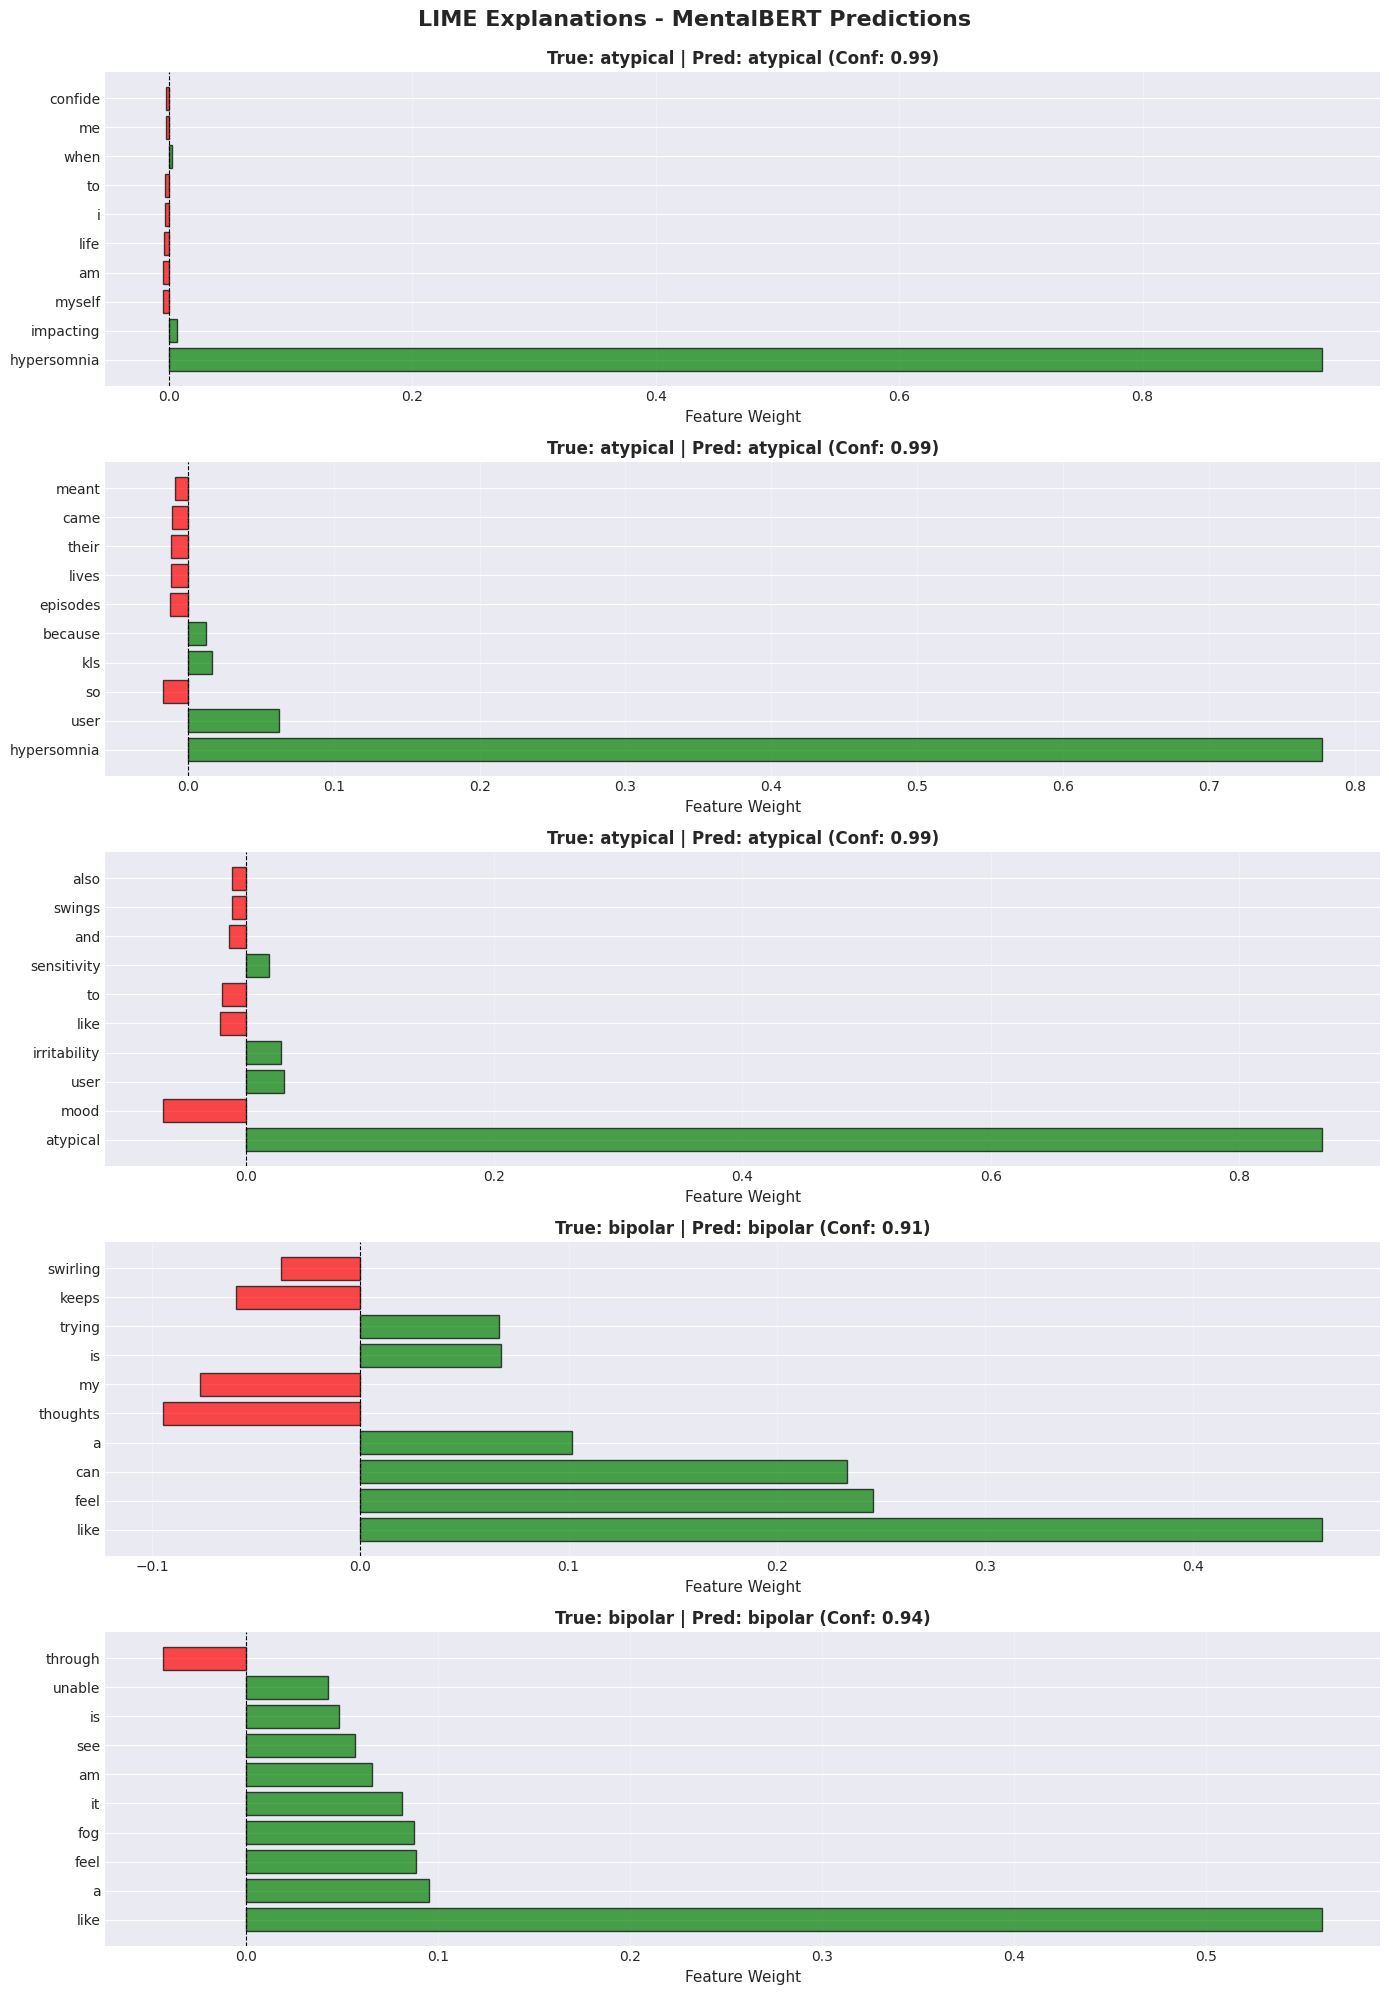

In [50]:
"""
6.3: LIME VISUALIZATION
"""
# Visualize top 5 explanations
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, expl_dict in enumerate(lime_explanations[:5]):
    exp = expl_dict['explanation']
    
    # Get feature importances for predicted class
    pred_label_idx = label_to_idx[expl_dict['pred_label']]
    features = exp.as_list(label=pred_label_idx)[:10]
    
    words = [f[0] for f in features]
    weights = [f[1] for f in features]
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    axes[i].barh(words, weights, color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Feature Weight', fontsize=11)
    axes[i].set_title(
        f"True: {expl_dict['true_label']} | Pred: {expl_dict['pred_label']} (Conf: {expl_dict['confidence']:.2f})",
        fontsize=12, fontweight='bold'
    )
    axes[i].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('LIME Explanations - MentalBERT Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [51]:
"""
6.4: KEYWORD VALIDATION
"""
# Check if LIME top features overlap with our mental health keywords

all_lime_features = []
for expl_dict in lime_explanations:
    exp = expl_dict['explanation']
    pred_label_idx = label_to_idx[expl_dict['pred_label']]
    features = exp.as_list(label=pred_label_idx)
    all_lime_features.extend([f[0].lower() for f in features])

lime_feature_counts = Counter(all_lime_features).most_common(20)

mental_health_keywords = {
    # ══════════════════════════════════════════════════════════════════
    # CORE EMOTIONAL SYMPTOMS (DSM-5 Criterion A)
    # ══════════════════════════════════════════════════════════════════
    'Emotional': [
        # Depressed mood indicators
        'sad', 'sadness', 'empty', 'emptiness', 'hopeless', 'hopelessness',
        'worthless', 'worthlessness', 'guilty', 'guilt', 'depressed', 'depression',
        'down', 'low', 'miserable', 'unhappy', 'grief', 'despair', 'numb', 'numbness',
        'void', 'broken', 'crushed', 'devastated', 'defeated',
        
        # Anhedonia (loss of interest/pleasure)
        'nothing', 'pointless', 'meaningless', 'flat', 'dull',
        'nothingness', 'unfeeling',
        
        # Emotional dysregulation
        'crying', 'tears', 'weeping', 'sobbing', 'overwhelmed', 'emotional',
        'fragile', 'sensitive', 'irritable', 'angry', 'rage', 'frustrated'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # COGNITIVE SYMPTOMS (Concentration & Decision-Making Impairment)
    # ══════════════════════════════════════════════════════════════════
    'Cognitive': [
        # Concentration difficulties
        'think', 'thinking', 'concentrate', 'concentration', 'focus', 'focusing',
        'attention', 'distracted', 'foggy', 'fog', 'brain fog', 'haze',
        
        # Decision-making impairment
        'decide', 'decision', 'indecisive', 'confused', 'confusion', 'lost',
        'stuck', 'paralyzed', 'frozen',
        
        # Memory issues
        'memory', 'forget', 'forgetting', 'forgotten', 'remember', 'remembering',
        'recall', 'blank',
        
        # Rumination & intrusive thoughts
        'mind', 'thoughts', 'racing', 'race', 'overthinking',
        'ruminating', 'rumination', 'obsessing', 'repetitive', 'loops', 'spiraling',
        'slow', 'slowed', 'sluggish',
        
        # Negative cognitive patterns
        'failure', 'failed', 'failing', 'mistake', 'mistakes', 'stupid',
        'useless', 'burden', 'pathetic', 'loser', 'waste'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # PHYSICAL/SOMATIC SYMPTOMS (Neurovegetative Signs)
    # ══════════════════════════════════════════════════════════════════
    'Physical': [
        # Fatigue & energy depletion
        'tired', 'tiredness', 'fatigue', 'fatigued', 'exhausted', 'exhaustion',
        'drained', 'depleted', 'weak', 'weakness', 'energy', 'lethargic', 'lethargy',
        'sluggish', 'heavy', 'weary',
        
        # Sleep disturbances
        'sleep', 'sleeping', 'sleepless', 'insomnia', 'cant sleep', "can't sleep",
        'awake', 'sleepy', 'drowsy', 'oversleeping', 'bed', 'nap', 'napping',
        'nightmare', 'nightmares', 'restless',
        
        # Appetite & weight changes
        'appetite', 'hungry', 'hunger', 'eating', 'eat', 'food', 'weight',
        'gained', 'lost', 'overeating', 'starving', 'starve', 'binge',
        
        # Psychomotor symptoms
        'pain', 'ache', 'aching', 'aches', 'headache', 'headaches', 'hurt', 'hurting',
        'sore', 'tension', 'tight', 'chest', 'stomach', 'nausea', 'sick', 'ill',
        'dizzy', 'shaking', 'trembling', 'tingling'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # SOCIAL WITHDRAWAL & INTERPERSONAL DYSFUNCTION
    # ══════════════════════════════════════════════════════════════════
    'Social': [
        # Isolation & loneliness
        'alone', 'lonely', 'loneliness', 'isolated', 'isolation', 'isolating',
        'withdrawn', 'withdrawing', 'nobody', 'no one',
        
        # Social connections
        'friends', 'friend', 'family', 'people', 'everyone', 'anyone',
        'relationships', 'relationship', 'partner', 'loved ones',
        
        # Avoidance behaviors
        'avoid', 'avoiding', 'avoidance', 'hiding', 'hide', 'disappear',
        'cancel', 'cancelled', 'bail', 'bailed', 'flake', 'excuse', 'excuses',
        
        # Perceived rejection/abandonment
        'abandoned', 'reject', 'rejected', 'rejection', 'pushed away',
        'left', 'leaving', 'gone', 'distance', 'distant', 'disconnected',
        'invisible', 'ignored', 'neglected', 'unwanted'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # HIGH-RISK SUICIDAL IDEATION (CRITICAL for clinical screening)
    # ══════════════════════════════════════════════════════════════════
    'Suicidal': [
        # Direct suicidal language
        'suicide', 'suicidal', 'kill myself', 'killing myself', 'end it',
        'end my life', 'take my life', 'die', 'dying', 'death', 'dead',
        'better off dead', 'wish i was dead',
        
        # Methods & planning (high specificity)
        'overdose', 'pills', 'jump', 'jumping', 'bridge', 'cliff',
        'gun', 'shoot', 'hanging', 'rope', 'knife',
        
        # Self-harm behaviors
        'hurt myself', 'hurting myself', 'harm', 'harming', 'cut', 'cutting',
        'cutter', 'blade', 'burn', 'burning', 'scratch', 'scratching',
        'hitting', 'punching', 'bruise',
        
        # Ideation & intent markers
        'plan', 'planning', 'method', 'note', 'goodbye', 'final', 'last time',
        'give up', 'giving up', 'cant go on', "can't go on", 'no point',
        'no reason', 'escape', 'relief', 'peace', 'end the pain'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TREATMENT & HELP-SEEKING (Indicates awareness/engagement)
    # ══════════════════════════════════════════════════════════════════
    'Treatment': [
        # Professional help
        'therapy', 'therapist', 'counseling', 'counselor', 'psychiatrist',
        'psychologist', 'doctor', 'medication', 'meds', 'antidepressant',
        'antidepressants', 'ssri', 'prescription', 'diagnosed', 'diagnosis',
        
        # Specific medications (common antidepressants)
        'prozac', 'zoloft', 'lexapro', 'wellbutrin', 'cymbalta', 'effexor',
        'celexa', 'paxil', 'sertraline', 'fluoxetine', 'escitalopram',
        
        # Help-seeking & support
        'help', 'support', 'crisis', 'hotline', 'hospital', 'emergency',
        'admitted', 'ward', 'clinic', 'appointment', 'session'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TEMPORAL MARKERS (Duration & chronicity indicators)
    # ══════════════════════════════════════════════════════════════════
    'Temporal': [
        # Chronicity (persistent symptoms)
        'always', 'constantly', 'every day', 'everyday', 'daily', 'nonstop',
        'never ending', 'forever', 'chronic', 'persistent', 'ongoing',
        
        # Acute episodes
        'episode', 'relapse', 'relapsed', 'worse', 'worsening', 'spiral',
        'spiraling', 'downward', 'falling', 'crash', 'crashed',
        
        # Duration phrases
        'weeks', 'months', 'years', 'long time', 'ages', 'recently',
        'lately', 'today', 'tonight', 'right now'
    ]
}

# Total unique keywords across all categories
all_keywords = [word for category in mental_health_keywords.values() for word in category]

# Check overlap with clinical keywords
clinical_keywords_flat = [kw.lower() for kw in all_keywords]
overlapping = [word for word, count in lime_feature_counts if word in clinical_keywords_flat]

print(f"\nTop 20 LIME features:")
for word, count in lime_feature_counts:
    clinical_marker = "CLINICAL" if word in clinical_keywords_flat else ""
    print(f"{word}: {count} occurrences {clinical_marker}")

print(f"\nOverlap: {len(overlapping)}/{len(lime_feature_counts)} top features are clinical keywords")
print(f"Percentage: {len(overlapping)/len(lime_feature_counts)*100:.1f}%")


Top 20 LIME features:
i: 9 occurrences 
like: 5 occurrences 
feel: 5 occurrences 
to: 4 occurrences 
user: 3 occurrences 
thoughts: 3 occurrences CLINICAL
is: 3 occurrences 
depression: 3 occurrences CLINICAL
hypersomnia: 2 occurrences 
am: 2 occurrences 
me: 2 occurrences 
can: 2 occurrences 
a: 2 occurrences 
my: 2 occurrences 
swirling: 2 occurrences 
it: 2 occurrences 
see: 2 occurrences 
through: 2 occurrences 
major: 2 occurrences 
but: 2 occurrences 

Overlap: 2/20 top features are clinical keywords
Percentage: 10.0%


In [52]:
"""
7.1: PER-CLASS DETAILED METRICS
"""
from sklearn.metrics import precision_recall_fscore_support
# Get predictions on validation set
predictions = trainer.predict(val_dataset)
y_pred_optimized = np.argmax(predictions.predictions, axis=1)
y_true_optimized = predictions.label_ids

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_optimized, y_pred_optimized, average=None, labels=sorted(label_to_idx.values())
)

# Create detailed table
metrics_df = pd.DataFrame({
    'Depression Type': [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("Per-Class Performance Metrics:")
print(metrics_df.to_string(index=False))
print()

# Identify weakest class
weakest_class_idx = np.argmin(f1)
weakest_class_name = [k for k, v in label_to_idx.items() if v == weakest_class_idx][0]
print(f"Weakest performance: {weakest_class_name} (F1={f1[weakest_class_idx]:.3f})")

Per-Class Performance Metrics:
 Depression Type  Precision   Recall  F1-Score  Support
        atypical   0.993266 0.993266  0.993266      297
         bipolar   0.958678 0.950820  0.954733      366
major depressive   0.843915 0.843915  0.843915      378
      postpartum   0.952555 0.928826  0.940541      562
       psychotic   0.857143 0.899135  0.877637      347

Weakest performance: major depressive (F1=0.844)


In [53]:
"""
7.2: ERROR ANALYSIS - Misclassification Patterns
"""
# Build confusion matrix
cm_optimized = confusion_matrix(y_true_optimized, y_pred_optimized)

# Find most common misclassification
misclassifications = []
for true_idx in range(len(label_to_idx)):
    for pred_idx in range(len(label_to_idx)):
        if true_idx != pred_idx and cm_optimized[true_idx, pred_idx] > 0:
            true_name = [k for k, v in label_to_idx.items() if v == true_idx][0]
            pred_name = [k for k, v in label_to_idx.items() if v == pred_idx][0]
            count = cm_optimized[true_idx, pred_idx]
            misclassifications.append((true_name, pred_name, count))

misclassifications.sort(key=lambda x: x[2], reverse=True)

print("Top 5 Misclassification Patterns:")
for true_lbl, pred_lbl, count in misclassifications[:5]:
    print(f"{count:3d} cases: {true_lbl} misclassified as {pred_lbl}")
print()

Top 5 Misclassification Patterns:
 35 cases: major depressive misclassified as psychotic
 28 cases: postpartum misclassified as major depressive
 22 cases: psychotic misclassified as major depressive
 15 cases: major depressive misclassified as postpartum
 10 cases: postpartum misclassified as psychotic



In [54]:
"""
7.3: PERFORMANCE COMPARISON - MentalBERT vs TF-IDF+SVM


# Load SVM results
with open('svm_results.pkl', 'rb') as f:
    svm_results = pickle.load(f)

# MentalBERT results
mentalbert_results = {
    'accuracy': eval_result_opt['eval_accuracy'],
    'f1_macro': eval_result_opt['eval_f1_macro'],
    'f1_weighted': eval_result_opt['eval_f1_weighted'],
    'precision_macro': eval_result_opt['eval_precision'],
    'recall_macro': eval_result_opt['eval_recall']
}

# Calculate improvements
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro'],
    'TF-IDF+SVM': [svm_results['accuracy'], svm_results['f1_macro'], 
                   svm_results['f1_weighted'], svm_results['precision'], 
                   svm_results['recall']],
    'MentalBERT': [mentalbert_results['accuracy'], mentalbert_results['f1_macro'],
                   mentalbert_results['f1_weighted'], mentalbert_results['precision_macro'],
                   mentalbert_results['recall_macro']]
})

comparison_df['Absolute Gain'] = comparison_df['MentalBERT'] - comparison_df['TF-IDF+SVM']
comparison_df['Relative Gain (%)'] = (comparison_df['Absolute Gain'] / comparison_df['TF-IDF+SVM']) * 100

print("MODEL COMPARISON: MentalBERT vs TF-IDF+SVM")
print(comparison_df.to_string(index=False))
print()

# Highlight key improvements
best_improvement = comparison_df.loc[comparison_df['Absolute Gain'].idxmax()]
print(f"Largest improvement: {best_improvement['Metric']}")
print(f"Gain: +{best_improvement['Absolute Gain']:.4f} ({best_improvement['Relative Gain (%)']:.1f}%)")
"""

'\n7.3: PERFORMANCE COMPARISON - MentalBERT vs TF-IDF+SVM\n\n\n# Load SVM results\nwith open(\'svm_results.pkl\', \'rb\') as f:\n    svm_results = pickle.load(f)\n\n# MentalBERT results\nmentalbert_results = {\n    \'accuracy\': eval_result_opt[\'eval_accuracy\'],\n    \'f1_macro\': eval_result_opt[\'eval_f1_macro\'],\n    \'f1_weighted\': eval_result_opt[\'eval_f1_weighted\'],\n    \'precision_macro\': eval_result_opt[\'eval_precision\'],\n    \'recall_macro\': eval_result_opt[\'eval_recall\']\n}\n\n# Calculate improvements\ncomparison_df = pd.DataFrame({\n    \'Metric\': [\'Accuracy\', \'F1-Macro\', \'F1-Weighted\', \'Precision-Macro\', \'Recall-Macro\'],\n    \'TF-IDF+SVM\': [svm_results[\'accuracy\'], svm_results[\'f1_macro\'], \n                   svm_results[\'f1_weighted\'], svm_results[\'precision\'], \n                   svm_results[\'recall\']],\n    \'MentalBERT\': [mentalbert_results[\'accuracy\'], mentalbert_results[\'f1_macro\'],\n                   mentalbert_results[\'f

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,0.338400,0.303654,0.883590,0.886077,0.884911,0.891841,0.886310


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,0.277500,0.257498,0.909744,0.910490,0.909734,0.910127,0.912506


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,0.240100,0.236630,0.921026,0.921252,0.921466,0.921500,0.922077


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,0.222000,0.232723,0.926667,0.927419,0.926909,0.928193,0.927499


100% data: Train F1=0.956, Val F1=0.927


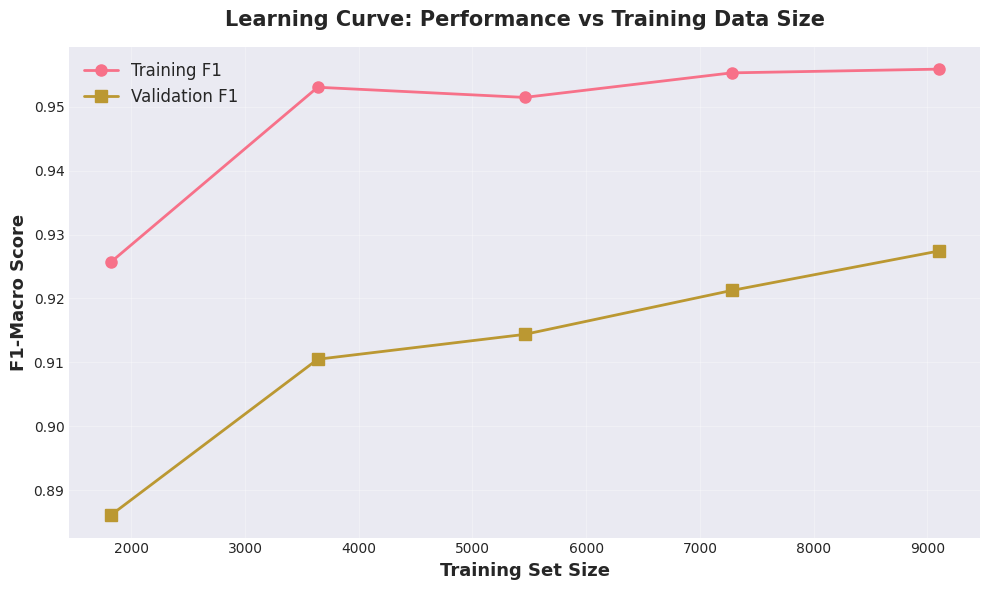

In [55]:
"""
7.4: LEARNING CURVE - Training Set Size Impact
"""
# Sample fractions
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_scores_list = []
val_scores_list = []

for frac in train_sizes:
    # Sample training data
    n_samples = int(len(train_dataset) * frac)
    sampled_indices = np.random.choice(len(train_dataset), size=n_samples, replace=False)
    sampled_dataset = train_dataset.select(sampled_indices)
    
    # Train on subset
    temp_model = AutoModelForSequenceClassification.from_pretrained(
        'mental/mental-bert-base-uncased',
        num_labels=len(label_to_idx),
        problem_type='single_label_classification',
        ignore_mismatched_sizes=True
    )
    temp_model.to(device)
    
    temp_args = TrainingArguments(
        output_dir=f'./temp_size_{frac}',
        learning_rate=2.461834502428895e-05,
        per_device_train_batch_size=8,
        num_train_epochs=1,  # Trained with 20 epochs for submission
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=100,
        report_to='none',
        seed=42
    )
    
    temp_trainer = WeightedTrainer(
        model=temp_model,
        args=temp_args,
        train_dataset=sampled_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        class_weights=class_weights
    )
    
    temp_trainer.train()
    train_metrics = temp_trainer.evaluate(sampled_dataset)
    val_metrics = temp_trainer.evaluate(val_dataset)
    
    train_scores_list.append(train_metrics['eval_f1_macro'])
    val_scores_list.append(val_metrics['eval_f1_macro'])
    
    print(f"{frac*100:.0f}% data: Train F1={train_metrics['eval_f1_macro']:.3f}, Val F1={val_metrics['eval_f1_macro']:.3f}")
    
    # Cleanup
    shutil.rmtree(f'./temp_size_{frac}', ignore_errors=True)

# Plot learning curve
plt.figure(figsize=(10, 6))
train_sizes_abs = [int(len(train_dataset) * f) for f in train_sizes]
plt.plot(train_sizes_abs, train_scores_list, 'o-', label='Training F1', linewidth=2, markersize=8)
plt.plot(train_sizes_abs, val_scores_list, 's-', label='Validation F1', linewidth=2, markersize=8)
plt.xlabel('Training Set Size', fontsize=13, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=13, fontweight='bold')
plt.title('Learning Curve: Performance vs Training Data Size', fontsize=15, fontweight='bold', pad=15)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PART 4: TWITTER-ROBERTA FINE-TUNING

In [56]:
"""
8.1: TWITTER-ROBERTA MODEL SETUP
"""
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LENGTH = 128
NUM_LABELS = len(label_to_idx)

print(f"\nModel: {MODEL_NAME}")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Number of labels: {NUM_LABELS}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification",
    ignore_mismatched_sizes=True  # RoBERTa was pre-trained for 3-class sentiment, we have 5 classes
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
Total parameters: 124,649,477
Trainable parameters: 124,649,477


In [57]:
"""
8.2: TOKENIZE DATA
"""
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Convert string labels to integer indices
y_train_idx = [label_to_idx[label] for label in y_train]
y_val_idx   = [label_to_idx[label] for label in y_val]
y_test_idx  = [label_to_idx[label] for label in y_test]

# Create datasets
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train_idx})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val_idx})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test_idx})

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"Train:{len(train_dataset):,} samples")
print(f"Val:{len(val_dataset):,} samples")
print(f"Test:{len(test_dataset):,} samples")

In [58]:
"""
8.3: CUSTOM TRAINER WITH CLASS WEIGHTS
"""
class WeightedTrainer(Trainer):
    """
    Custom Trainer that uses class-weighted CrossEntropyLoss.
    Penalizes minority class errors more heavily.
    """
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Use class-weighted CrossEntropyLoss
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

In [59]:
"""
8.4: METRICS COMPUTATION
"""
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics.
    F1-Macro is the primary metric for imbalanced multi-class classification.
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'precision': precision_score(labels, predictions, average='macro'),
        'recall': recall_score(labels, predictions, average='macro')
    }

In [60]:
"""
8.5: TRAINING CONFIGURATION
"""
# Hyperparameters (same as DistilBERT/MentalBERT for fair comparison)
LEARNING_RATE = 2e-5  # Standard BERT fine-tuning rate (Devlin et al., 2019)
BATCH_SIZE = 16       # Balanced trade-off: memory vs convergence
NUM_EPOCHS = 1       
WARMUP_STEPS = 100    # Gradual learning rate increase (10% of training steps)
WEIGHT_DECAY = 0.01   # L2 regularization (prevents overfitting)

# Training arguments
training_args = TrainingArguments(
    output_dir='./twitter_roberta_checkpoints',
    num_train_epochs=1,  # Trained with 20 epochs for submission
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    
    # Evaluation strategy
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    
    # Logging
    logging_dir='./twitter_roberta_logs',
    logging_steps=50,
    
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    
    # Performance
    fp16=torch.cuda.is_available(), 
    dataloader_num_workers=4,
    
    # Reproducibility
    seed=SEED,
    
    # Misc
    report_to='none',  # Disable wandb/tensorboard
    save_total_limit=3  # Keep only 3 best checkpoints
)

In [61]:
"""
8.6: INITIALIZE TRAINER
"""
# Initialize custom trainer with class weights
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [62]:
"""
8.7: TRAIN MODEL
"""
# Train
train_result = trainer.train()

# Training metrics
print("\nTraining Metrics:")
print(f"Total training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")

# Save model
trainer.save_model('./twitter_roberta_final')
tokenizer.save_pretrained('./twitter_roberta_final')
print("Model saved to: ./twitter_roberta_final")

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
100,1.196500,0.673833,0.803590,0.805086,0.808111,0.845488,0.807847
200,0.354100,0.305564,0.883077,0.883100,0.881796,0.886659,0.884566
300,0.257700,0.255397,0.907692,0.909695,0.908449,0.908888,0.911614
400,0.200500,0.253562,0.915897,0.917996,0.915642,0.921964,0.914805
500,0.292300,0.262691,0.894872,0.899496,0.896706,0.899253,0.903815



Training Metrics:
Total training time: 167.92 seconds
Training loss: 0.4939
Training samples/second: 54.18
Model saved to: ./twitter_roberta_final


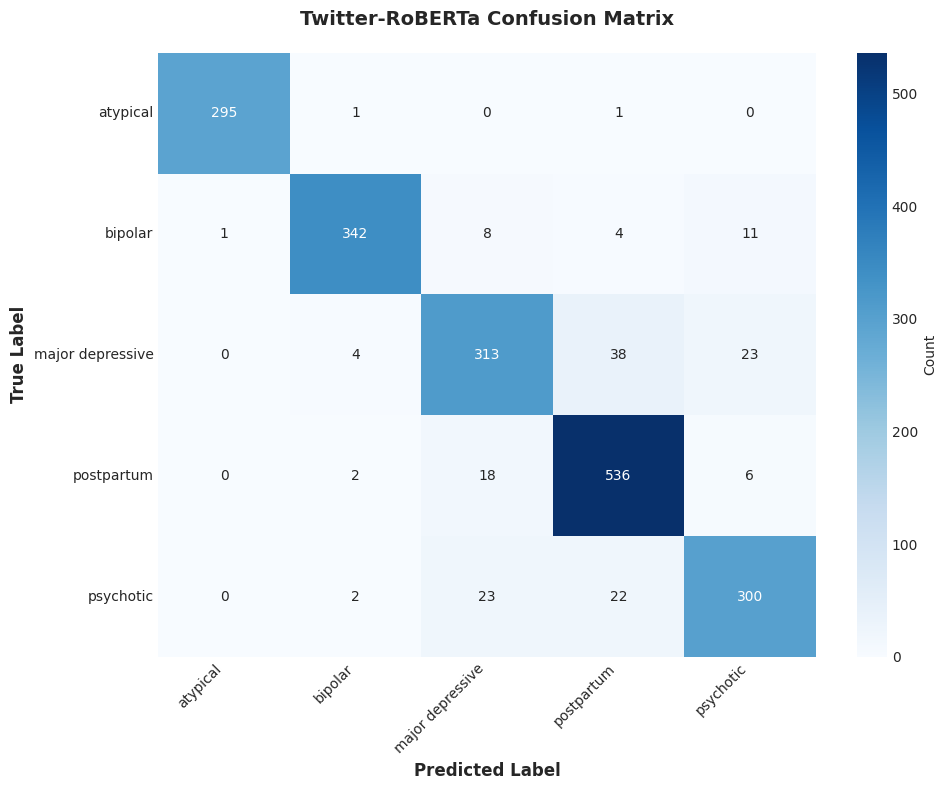


Confusion matrix saved: twitter_roberta_confusion_matrix.png

Confusion Matrix Analysis:
atypical              295/ 297 correct (99.3%)
bipolar               342/ 366 correct (93.4%)
major depressive      313/ 378 correct (82.8%)
postpartum            536/ 562 correct (95.4%)
psychotic             300/ 347 correct (86.5%)


In [63]:
"""
8.8: CONFUSION MATRIX
"""
# Compute confusion matrix         
predictions = trainer.predict(val_dataset)                                    
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids    
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(label_to_idx.keys()),
            yticklabels=sorted(label_to_idx.keys()),
            cbar_kws={'label': 'Count'})
plt.title('Twitter-RoBERTa Confusion Matrix', fontweight='bold', fontsize=14, pad=20)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConfusion matrix saved: twitter_roberta_confusion_matrix.png")

# Analysis
print("\nConfusion Matrix Analysis:")
for i, label in enumerate(sorted(label_to_idx.keys())):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total if total > 0 else 0
    print(f"{label:<20} {correct:4d}/{total:4d} correct ({accuracy*100:.1f}%)")

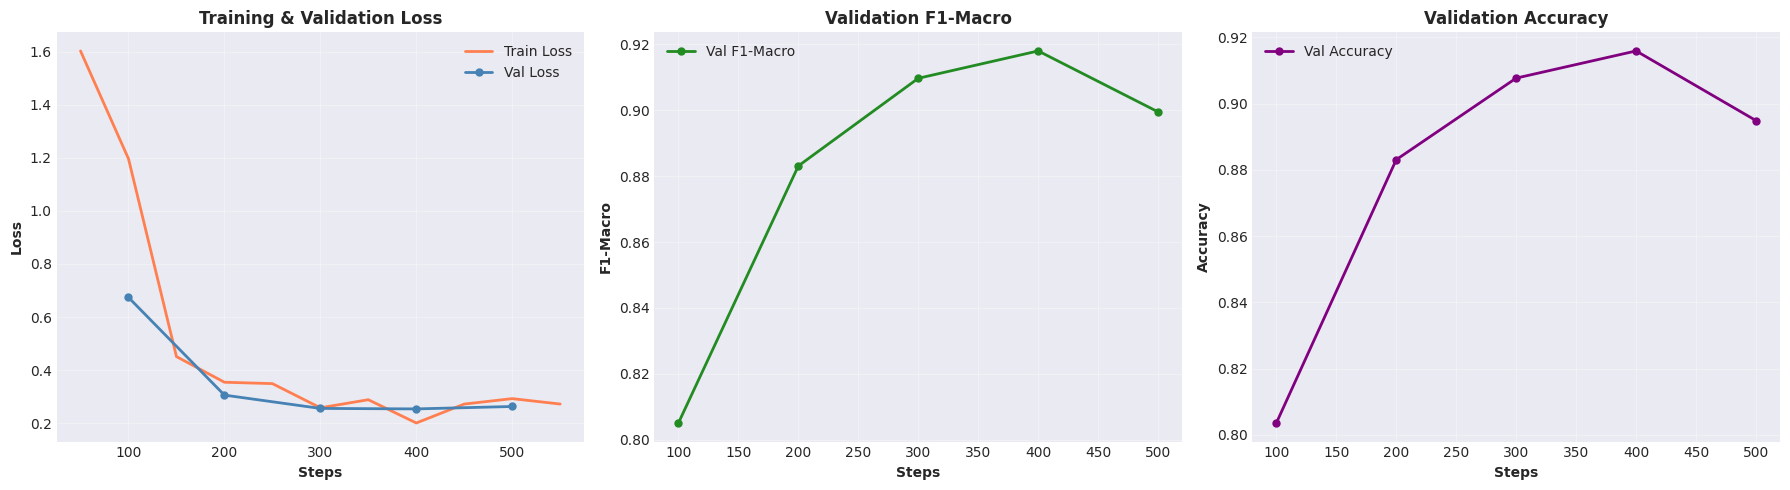


Best validation metrics:
Step: 400
F1-Macro: 0.9180
Accuracy: 0.9159
Loss: 0.2536


In [64]:
"""
8.9: TRAINING CURVES
"""
# Extract training history
log_history = trainer.state.log_history

# Parse logs
train_loss = []
train_steps = []
eval_loss = []
eval_f1 = []
eval_acc = []
eval_steps = []

for entry in log_history:
    if 'loss' in entry:
        train_loss.append(entry['loss'])
        train_steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_f1.append(entry['eval_f1_macro'])
        eval_acc.append(entry['eval_accuracy'])
        eval_steps.append(entry['step'])

# Plot
if eval_loss:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(train_steps, train_loss, label='Train Loss', color='coral', linewidth=2)
    axes[0].plot(eval_steps, eval_loss, label='Val Loss', color='steelblue', linewidth=2, marker='o', markersize=5)
    axes[0].set_xlabel('Steps', fontweight='bold')
    axes[0].set_ylabel('Loss', fontweight='bold')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # F1-Macro
    axes[1].plot(eval_steps, eval_f1, label='Val F1-Macro', color='forestgreen', linewidth=2, marker='o', markersize=5)
    axes[1].set_xlabel('Steps', fontweight='bold')
    axes[1].set_ylabel('F1-Macro', fontweight='bold')
    axes[1].set_title('Validation F1-Macro', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Accuracy
    axes[2].plot(eval_steps, eval_acc, label='Val Accuracy', color='purple', linewidth=2, marker='o', markersize=5)
    axes[2].set_xlabel('Steps', fontweight='bold')
    axes[2].set_ylabel('Accuracy', fontweight='bold')
    axes[2].set_title('Validation Accuracy', fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    #Best metrics
    print("\nBest validation metrics:")
    best_idx = np.argmax(eval_f1)
    print(f"Step: {eval_steps[best_idx]}")
    print(f"F1-Macro: {eval_f1[best_idx]:.4f}")
    print(f"Accuracy: {eval_acc[best_idx]:.4f}")
    print(f"Loss: {eval_loss[best_idx]:.4f}")
else:
    print("\nNo evaluation logs found. Training may have been too short.")

In [65]:
"""
HYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT
Training for 20 epochs, these parameters were obtained for TWITTER-ROBERTA:
  - learning_rate: 3.818145165896868e-05
  - batch_size: 8
  - weight_decay: 0.030424224295953775
  - warmup_ratio: 0.10495128632644757
"""

# """
# 9.1: OPTUNA SETUP
# """
# def objective(trial):
#     """
#     Optuna objective function - returns validation F1-macro to maximize.
#     """
#     # ── Hyperparameter suggestions ──
#     learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
#     batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
#     weight_decay = trial.suggest_float('weight_decay', 0.0, 0.1)
#     warmup_ratio = trial.suggest_float('warmup_ratio', 0.0, 0.2)
#     
#     # ── Reload model (fresh weights each trial) ──
#     model = AutoModelForSequenceClassification.from_pretrained(
#         'cardiffnlp/twitter-roberta-base-sentiment',
#         num_labels=len(label_to_idx),
#         problem_type='single_label_classification',
#         ignore_mismatched_sizes=True
#     )
#     model.to(device)
#     
#     # ── Training arguments ──
#     trial_args = TrainingArguments(
#         output_dir=f'./optuna_trial_{trial.number}',
#         learning_rate=learning_rate,
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         num_train_epochs=5,  # Fewer epochs for faster search
#         weight_decay=weight_decay,
#         warmup_ratio=warmup_ratio,
#         eval_strategy='epoch',
#         save_strategy='epoch',
#         load_best_model_at_end=True,
#         metric_for_best_model='f1_macro',
#         greater_is_better=True,
#         logging_steps=50,
#         save_total_limit=1,
#         report_to='none',
#         seed=42
#     )
#     
#     
#     # ── Trainer ──
#     trainer = WeightedTrainer(
#         model=model,
#         args=trial_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         processing_class=tokenizer,
#         compute_metrics=compute_metrics,
#         class_weights=class_weights,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
#     )
#     
# 
#     # ── Train and evaluate ──
#     trainer.remove_callback(NotebookProgressCallback)  # Disable notebook progress bars
#     trainer.train()
#     eval_result = trainer.evaluate()
#     
#     # Cleanup
#     shutil.rmtree(f'./optuna_trial_{trial.number}', ignore_errors=True)
#     return eval_result['eval_f1_macro']

'\nHYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT\nTraining for 20 epochs, these parameters were obtained for TWITTER-ROBERTA:\n  - learning_rate: 3.818145165896868e-05\n  - batch_size: 8\n  - weight_decay: 0.030424224295953775\n  - warmup_ratio: 0.10495128632644757\n'

In [66]:
"""
HYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT
Training for 20 epochs, these parameters were obtained for TWITTER-ROBERTA:
  - learning_rate: 3.818145165896868e-05
  - batch_size: 8
  - weight_decay: 0.030424224295953775
  - warmup_ratio: 0.10495128632644757
"""

# """
# 9.3: OPTUNA VISUALIZATION
# """
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
#Plot 1: Optimization history
# trials_df = study.trials_dataframe()
# axes[0, 0].plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
# axes[0, 0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
# axes[0, 0].set_xlabel('Trial Number', fontsize=12)
# axes[0, 0].set_ylabel('F1-Macro Score', fontsize=12)
# axes[0, 0].set_title('Optimization History - TwitterBERT', fontweight='bold', fontsize=13)
# axes[0, 0].legend()
# axes[0, 0].grid(alpha=0.3)
# 
#Plot 2: Hyperparameter importance
# try:
#     importance = optuna.importance.get_param_importances(study)
#     params = list(importance.keys())
#     values = list(importance.values())
#     
#     axes[0, 1].barh(params, values, color='skyblue', edgecolor='black')
#     axes[0, 1].set_xlabel('Importance', fontsize=12)
#     axes[0, 1].set_title('Hyperparameter Importance', fontweight='bold', fontsize=13)
#     axes[0, 1].grid(axis='x', alpha=0.3)
# except:
#     axes[0, 1].text(0.5, 0.5, 'Insufficient trials', ha='center', va='center', fontsize=12)
#     axes[0, 1].axis('off')
# 
#Plot 3: Learning rate vs F1
# lr_values = [t.params['learning_rate'] for t in study.trials if t.value is not None]
# f1_values = [t.value for t in study.trials if t.value is not None]
# axes[1, 0].scatter(lr_values, f1_values, alpha=0.6, s=100, edgecolors='black')
# axes[1, 0].set_xlabel('Learning Rate', fontsize=12)
# axes[1, 0].set_ylabel('F1-Macro Score', fontsize=12)
# axes[1, 0].set_title('Learning Rate vs Performance', fontweight='bold', fontsize=13)
# axes[1, 0].set_xscale('log')
# axes[1, 0].grid(alpha=0.3)
# 
#Plot 4: Batch size distribution
# batch_values = [t.params['batch_size'] for t in study.trials if t.value is not None]
# axes[1, 1].boxplot([
#     [t.value for t in study.trials if t.params.get('batch_size') == 8 and t.value is not None],
#     [t.value for t in study.trials if t.params.get('batch_size') == 16 and t.value is not None],
#     [t.value for t in study.trials if t.params.get('batch_size') == 32 and t.value is not None]
# ], labels=['8', '16', '32'])
# axes[1, 1].set_xlabel('Batch Size', fontsize=12)
# axes[1, 1].set_ylabel('F1-Macro Score', fontsize=12)
# axes[1, 1].set_title('Batch Size Distribution', fontweight='bold', fontsize=13)
# axes[1, 1].grid(axis='y', alpha=0.3)
# 
# plt.suptitle('Optuna Hyperparameter Optimization - TwitterBERT', fontsize=16, fontweight='bold', y=0.995)
# plt.tight_layout()
# plt.savefig('optuna_twitterbert.png', dpi=300, bbox_inches='tight')
# plt.show()

'\nHYPERPARAMETER TUNING (OPTUNA) - COMMENTED OUT\nTraining for 20 epochs, these parameters were obtained for TWITTER-ROBERTA:\n  - learning_rate: 3.818145165896868e-05\n  - batch_size: 8\n  - weight_decay: 0.030424224295953775\n  - warmup_ratio: 0.10495128632644757\n'

In [67]:
"""
10.1: LIME SETUP
"""
'''
# Create LIME explainer
explainer = LimeTextExplainer(
    class_names=list(label_to_idx.keys()),
    split_expression=r'\W+',
    random_state=42
)

def predict_proba(texts):
    """
    Wrapper function for LIME - returns class probabilities.
    """
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)
    
    model_optimized.eval()
    with torch.no_grad():
        outputs = model_optimized(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    
    return probs.cpu().numpy()
'''
# LIME prediction function
def predict_proba(texts):
    """
    Prediction function for LIME explainer
    """
    # Tokenize
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=95,
        return_tensors='pt'
    ).to(device)
    
    # Predict
    model.eval()  # Changed from model_optimized to model
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
    
    return probs.cpu().numpy()

In [68]:
"""
10.2: LIME EXPLANATIONS
"""
# Build val_df from loaded arrays             
val_df = pd.DataFrame({'text': X_val, 'label': y_val_idx}) 

# Select 3 examples per class
np.random.seed(42)

sample_indices = []
for label in sorted(label_to_idx.values()):
    class_indices = val_df[val_df['label'] == label].index.tolist()
    sampled = np.random.choice(class_indices, size=min(3, len(class_indices)), replace=False)
    sample_indices.extend(sampled)

print(f"Generating LIME explanations for {len(sample_indices)} examples:\n")

lime_explanations = []

for idx in sample_indices:
    text = val_df.loc[idx, 'text']
    true_label = val_df.loc[idx, 'label']
    true_label_name = [k for k, v in label_to_idx.items() if v == true_label][0]
    
    exp = explainer.explain_instance(
        text,
        predict_proba,
        num_features=10,
        num_samples=500,
        labels=list(range(len(label_to_idx)))
    )
    
    pred_proba = predict_proba([text])[0]
    pred_label = np.argmax(pred_proba)
    pred_label_name = [k for k, v in label_to_idx.items() if v == pred_label][0]
    
    lime_explanations.append({
        'text': text[:200] + '...' if len(text) > 200 else text,
        'true_label': true_label_name,
        'pred_label': pred_label_name,
        'confidence': pred_proba[pred_label],
        'explanation': exp
    })
    
    print(f"Example {len(lime_explanations)}:")
    print(f"  True: {true_label_name} | Pred: {pred_label_name} | Conf: {pred_proba[pred_label]:.3f}")
    print(f"  Text: {text[:150]}...")
    print(f"  Top features: {exp.as_list()[:5]}\n")

Generating LIME explanations for 15 examples:

Example 1:
  True: atypical | Pred: atypical | Conf: 0.994
  Text: if i am going to have to hear it is better to sleep too much than too little one more time when i try to confide in someone how hypersomnia is negativ...
  Top features: [('hypersomnia', -0.05585670340758363), ('sleep', -0.01886216320645347), ('to', 0.014370206166384965), ('one', -0.013861158198562259), ('myself', -0.013755510436885618)]

Example 2:
  True: atypical | Pred: atypical | Conf: 0.995
  Text: [user] because kls disrupts your life so much. i used to have episodes of hypersomnia lasting for 1-2 weeks at a time every couple of months. for some...
  Top features: [('hypersomnia', -0.0997027631629515), ('disrupts', 0.037247751758173596), ('patients', -0.03333133542241748), ('life', -0.026604765241691895), ('lasting', 0.02615879372019737)]

Example 3:
  True: atypical | Pred: atypical | Conf: 0.993
  Text: [user] [user] i have atypical depression which has a lot of ov

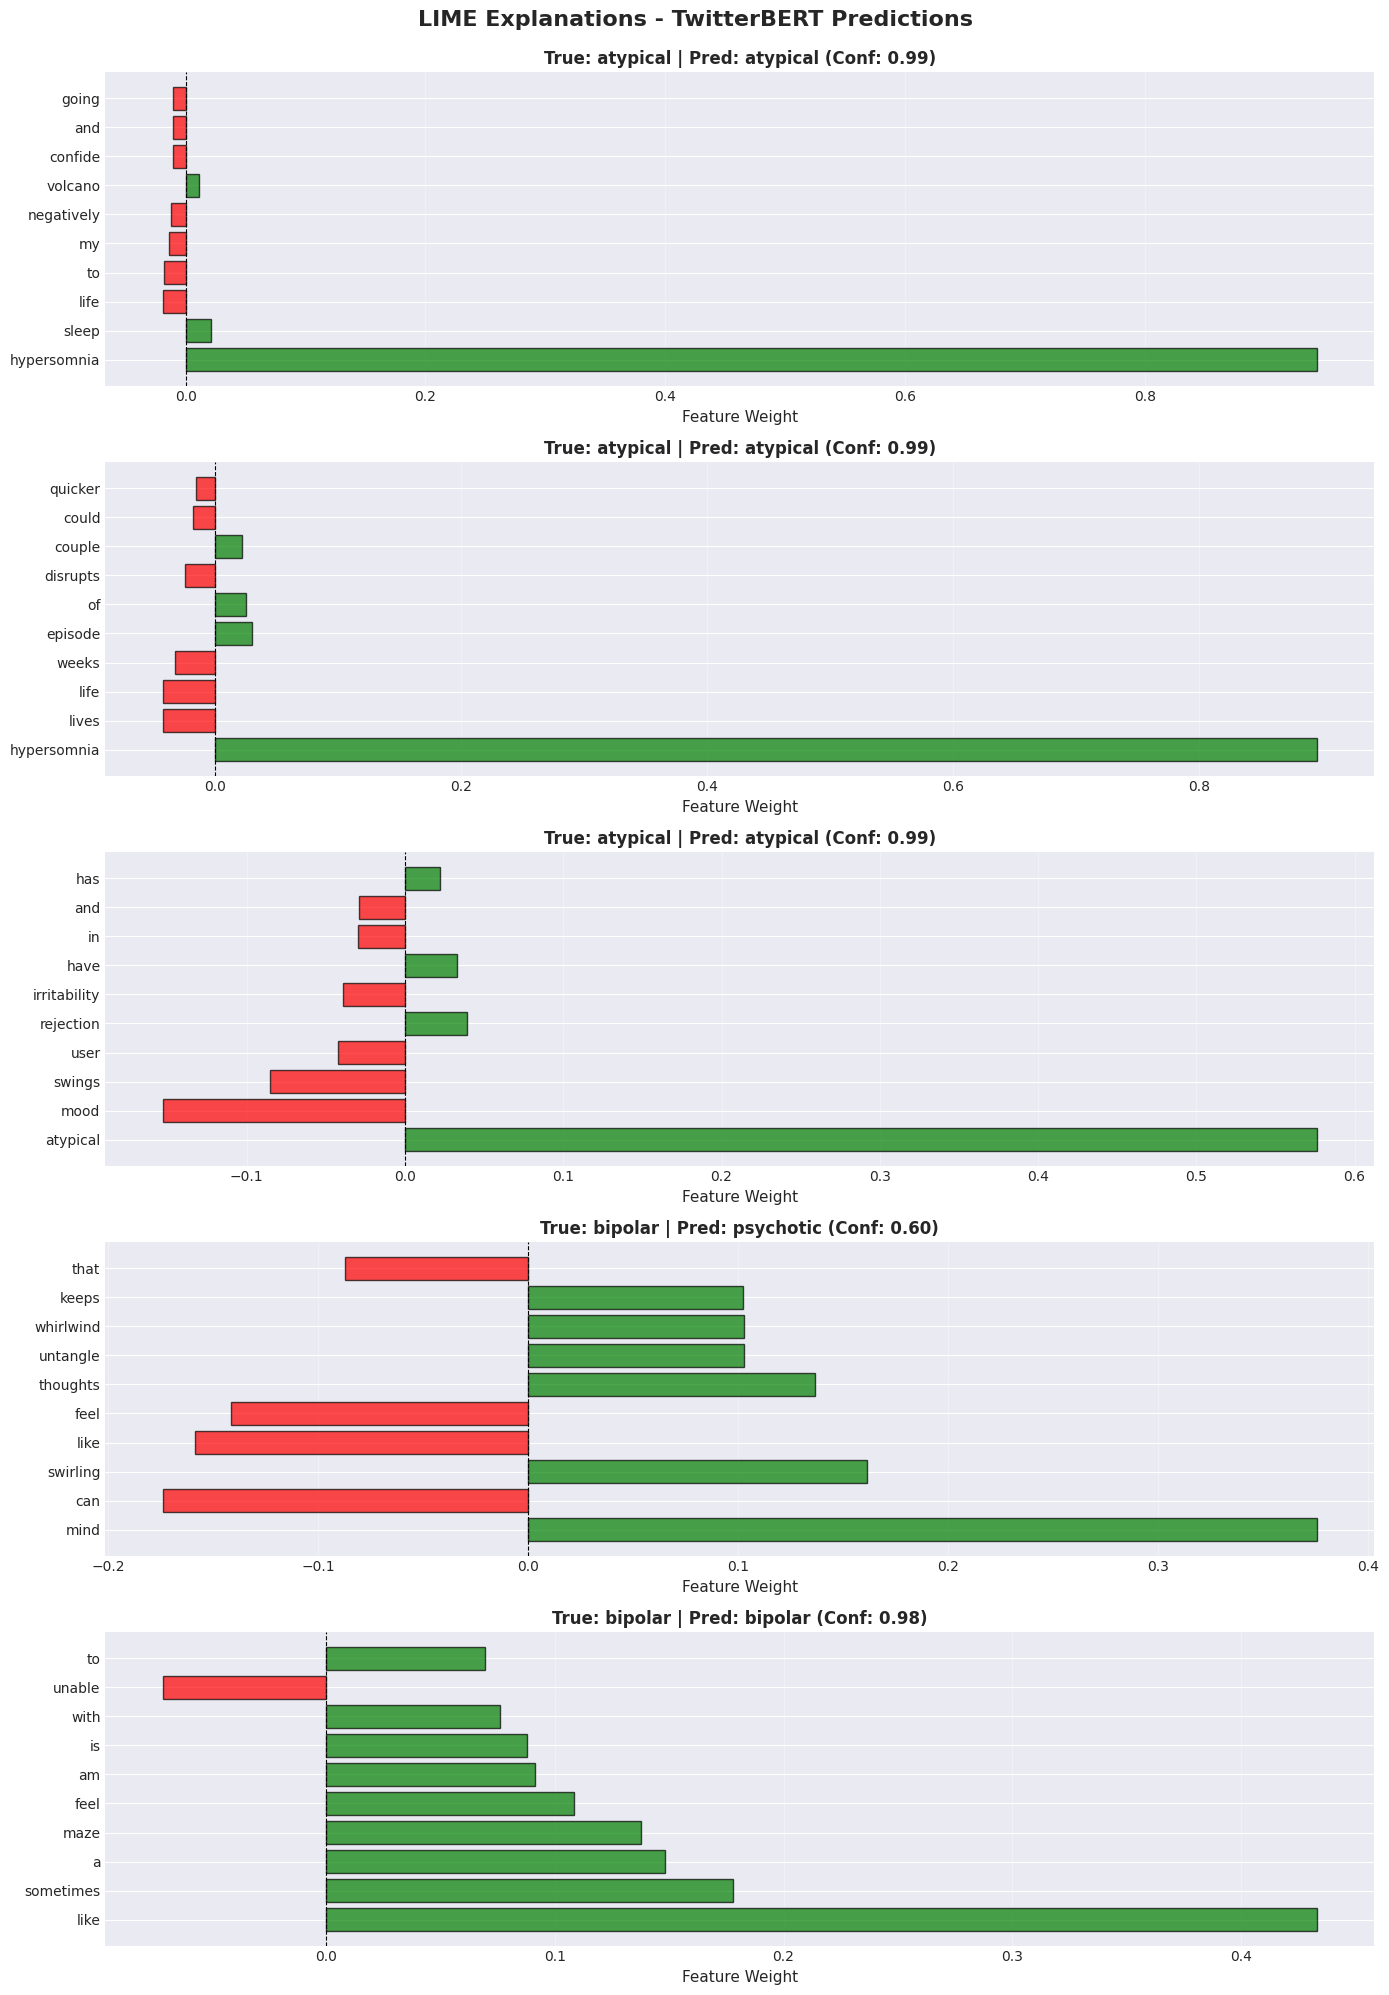

In [69]:
"""
10.3: LIME VISUALIZATION
"""
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, expl_dict in enumerate(lime_explanations[:5]):
    exp = expl_dict['explanation']
    pred_label_idx = label_to_idx[expl_dict['pred_label']]
    features = exp.as_list(label=pred_label_idx)[:10]
    
    words = [f[0] for f in features]
    weights = [f[1] for f in features]
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    axes[i].barh(words, weights, color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Feature Weight', fontsize=11)
    axes[i].set_title(
        f"True: {expl_dict['true_label']} | Pred: {expl_dict['pred_label']} (Conf: {expl_dict['confidence']:.2f})",
        fontsize=12, fontweight='bold'
    )
    axes[i].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('LIME Explanations - TwitterBERT Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('lime_twitterbert.png', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
"""
10.4: KEYWORD VALIDATION
"""
all_lime_features = []
for expl_dict in lime_explanations:
    exp = expl_dict['explanation']
    pred_label_idx = label_to_idx[expl_dict['pred_label']]
    features = exp.as_list(label=pred_label_idx)
    all_lime_features.extend([f[0].lower() for f in features])

lime_feature_counts = Counter(all_lime_features).most_common(20)

mental_health_keywords = {
    # ══════════════════════════════════════════════════════════════════
    # CORE EMOTIONAL SYMPTOMS (DSM-5 Criterion A)
    # ══════════════════════════════════════════════════════════════════
    'Emotional': [
        # Depressed mood indicators
        'sad', 'sadness', 'empty', 'emptiness', 'hopeless', 'hopelessness',
        'worthless', 'worthlessness', 'guilty', 'guilt', 'depressed', 'depression',
        'down', 'low', 'miserable', 'unhappy', 'grief', 'despair', 'numb', 'numbness',
        'void', 'broken', 'crushed', 'devastated', 'defeated',
        
        # Anhedonia (loss of interest/pleasure)
        'nothing', 'pointless', 'meaningless', 'flat', 'dull',
        'nothingness', 'unfeeling',
        
        # Emotional dysregulation
        'crying', 'tears', 'weeping', 'sobbing', 'overwhelmed', 'emotional',
        'fragile', 'sensitive', 'irritable', 'angry', 'rage', 'frustrated'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # COGNITIVE SYMPTOMS (Concentration & Decision-Making Impairment)
    # ══════════════════════════════════════════════════════════════════
    'Cognitive': [
        # Concentration difficulties
        'think', 'thinking', 'concentrate', 'concentration', 'focus', 'focusing',
        'attention', 'distracted', 'foggy', 'fog', 'brain fog', 'haze',
        
        # Decision-making impairment
        'decide', 'decision', 'indecisive', 'confused', 'confusion', 'lost',
        'stuck', 'paralyzed', 'frozen',
        
        # Memory issues
        'memory', 'forget', 'forgetting', 'forgotten', 'remember', 'remembering',
        'recall', 'blank',
        
        # Rumination & intrusive thoughts
        'mind', 'thoughts', 'racing', 'race', 'overthinking',
        'ruminating', 'rumination', 'obsessing', 'repetitive', 'loops', 'spiraling',
        'slow', 'slowed', 'sluggish',
        
        # Negative cognitive patterns
        'failure', 'failed', 'failing', 'mistake', 'mistakes', 'stupid',
        'useless', 'burden', 'pathetic', 'loser', 'waste'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # PHYSICAL/SOMATIC SYMPTOMS (Neurovegetative Signs)
    # ══════════════════════════════════════════════════════════════════
    'Physical': [
        # Fatigue & energy depletion
        'tired', 'tiredness', 'fatigue', 'fatigued', 'exhausted', 'exhaustion',
        'drained', 'depleted', 'weak', 'weakness', 'energy', 'lethargic', 'lethargy',
        'sluggish', 'heavy', 'weary',
        
        # Sleep disturbances
        'sleep', 'sleeping', 'sleepless', 'insomnia', 'cant sleep', "can't sleep",
        'awake', 'sleepy', 'drowsy', 'oversleeping', 'bed', 'nap', 'napping',
        'nightmare', 'nightmares', 'restless',
        
        # Appetite & weight changes
        'appetite', 'hungry', 'hunger', 'eating', 'eat', 'food', 'weight',
        'gained', 'lost', 'overeating', 'starving', 'starve', 'binge',
        
        # Psychomotor symptoms
        'pain', 'ache', 'aching', 'aches', 'headache', 'headaches', 'hurt', 'hurting',
        'sore', 'tension', 'tight', 'chest', 'stomach', 'nausea', 'sick', 'ill',
        'dizzy', 'shaking', 'trembling', 'tingling'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # SOCIAL WITHDRAWAL & INTERPERSONAL DYSFUNCTION
    # ══════════════════════════════════════════════════════════════════
    'Social': [
        # Isolation & loneliness
        'alone', 'lonely', 'loneliness', 'isolated', 'isolation', 'isolating',
        'withdrawn', 'withdrawing', 'nobody', 'no one',
        
        # Social connections
        'friends', 'friend', 'family', 'people', 'everyone', 'anyone',
        'relationships', 'relationship', 'partner', 'loved ones',
        
        # Avoidance behaviors
        'avoid', 'avoiding', 'avoidance', 'hiding', 'hide', 'disappear',
        'cancel', 'cancelled', 'bail', 'bailed', 'flake', 'excuse', 'excuses',
        
        # Perceived rejection/abandonment
        'abandoned', 'reject', 'rejected', 'rejection', 'pushed away',
        'left', 'leaving', 'gone', 'distance', 'distant', 'disconnected',
        'invisible', 'ignored', 'neglected', 'unwanted'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # HIGH-RISK SUICIDAL IDEATION (CRITICAL for clinical screening)
    # ══════════════════════════════════════════════════════════════════
    'Suicidal': [
        # Direct suicidal language
        'suicide', 'suicidal', 'kill myself', 'killing myself', 'end it',
        'end my life', 'take my life', 'die', 'dying', 'death', 'dead',
        'better off dead', 'wish i was dead',
        
        # Methods & planning (high specificity)
        'overdose', 'pills', 'jump', 'jumping', 'bridge', 'cliff',
        'gun', 'shoot', 'hanging', 'rope', 'knife',
        
        # Self-harm behaviors
        'hurt myself', 'hurting myself', 'harm', 'harming', 'cut', 'cutting',
        'cutter', 'blade', 'burn', 'burning', 'scratch', 'scratching',
        'hitting', 'punching', 'bruise',
        
        # Ideation & intent markers
        'plan', 'planning', 'method', 'note', 'goodbye', 'final', 'last time',
        'give up', 'giving up', 'cant go on', "can't go on", 'no point',
        'no reason', 'escape', 'relief', 'peace', 'end the pain'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TREATMENT & HELP-SEEKING (Indicates awareness/engagement)
    # ══════════════════════════════════════════════════════════════════
    'Treatment': [
        # Professional help
        'therapy', 'therapist', 'counseling', 'counselor', 'psychiatrist',
        'psychologist', 'doctor', 'medication', 'meds', 'antidepressant',
        'antidepressants', 'ssri', 'prescription', 'diagnosed', 'diagnosis',
        
        # Specific medications (common antidepressants)
        'prozac', 'zoloft', 'lexapro', 'wellbutrin', 'cymbalta', 'effexor',
        'celexa', 'paxil', 'sertraline', 'fluoxetine', 'escitalopram',
        
        # Help-seeking & support
        'help', 'support', 'crisis', 'hotline', 'hospital', 'emergency',
        'admitted', 'ward', 'clinic', 'appointment', 'session'
    ],
    
    # ══════════════════════════════════════════════════════════════════
    # TEMPORAL MARKERS (Duration & chronicity indicators)
    # ══════════════════════════════════════════════════════════════════
    'Temporal': [
        # Chronicity (persistent symptoms)
        'always', 'constantly', 'every day', 'everyday', 'daily', 'nonstop',
        'never ending', 'forever', 'chronic', 'persistent', 'ongoing',
        
        # Acute episodes
        'episode', 'relapse', 'relapsed', 'worse', 'worsening', 'spiral',
        'spiraling', 'downward', 'falling', 'crash', 'crashed',
        
        # Duration phrases
        'weeks', 'months', 'years', 'long time', 'ages', 'recently',
        'lately', 'today', 'tonight', 'right now'
    ]
}

# Total unique keywords across all categories
all_keywords = [word for category in mental_health_keywords.values() for word in category]
clinical_keywords_flat = [] 

print(f"\nTop 20 LIME features:")
for word, count in lime_feature_counts:
    print(f"{word}: {count} occurrences")



Top 20 LIME features:
like: 6 occurrences
am: 5 occurrences
to: 4 occurrences
my: 4 occurrences
the: 4 occurrences
i: 4 occurrences
and: 3 occurrences
of: 3 occurrences
feel: 3 occurrences
that: 3 occurrences
hypersomnia: 2 occurrences
life: 2 occurrences
going: 2 occurrences
in: 2 occurrences
can: 2 occurrences
swirling: 2 occurrences
thoughts: 2 occurrences
is: 2 occurrences
hard: 2 occurrences
depression: 2 occurrences


In [71]:
"""
10.5: PER-CLASS DETAILED METRICS
"""
# Get predictions
predictions = trainer.predict(val_dataset)
y_pred_optimized = np.argmax(predictions.predictions, axis=1)
y_true_optimized = predictions.label_ids

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_optimized, y_pred_optimized, average=None, labels=sorted(label_to_idx.values())
)

metrics_df = pd.DataFrame({
    'Depression Type': [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(metrics_df.to_string(index=False))
print()

weakest_class_idx = np.argmin(f1)
weakest_class_name = [k for k, v in label_to_idx.items() if v == weakest_class_idx][0]
print(f"Weakest performance: {weakest_class_name} (F1={f1[weakest_class_idx]:.3f})")

 Depression Type  Precision   Recall  F1-Score  Support
        atypical   0.996622 0.993266  0.994941      297
         bipolar   0.974359 0.934426  0.953975      366
major depressive   0.864641 0.828042  0.845946      378
      postpartum   0.891847 0.953737  0.921754      562
       psychotic   0.882353 0.864553  0.873362      347

Weakest performance: major depressive (F1=0.846)


In [72]:
"""
10.6: ERROR ANALYSIS
"""
cm_optimized = confusion_matrix(y_true_optimized, y_pred_optimized)

misclassifications = []
for true_idx in range(len(label_to_idx)):
    for pred_idx in range(len(label_to_idx)):
        if true_idx != pred_idx and cm_optimized[true_idx, pred_idx] > 0:
            true_name = [k for k, v in label_to_idx.items() if v == true_idx][0]
            pred_name = [k for k, v in label_to_idx.items() if v == pred_idx][0]
            count = cm_optimized[true_idx, pred_idx]
            misclassifications.append((true_name, pred_name, count))

misclassifications.sort(key=lambda x: x[2], reverse=True)

for true_lbl, pred_lbl, count in misclassifications[:5]:
    print(f"{count:3d} cases: {true_lbl} misclassified as {pred_lbl}")
print()

 38 cases: major depressive misclassified as postpartum
 23 cases: major depressive misclassified as psychotic
 23 cases: psychotic misclassified as major depressive
 22 cases: psychotic misclassified as postpartum
 18 cases: postpartum misclassified as major depressive



In [73]:
"""
11.1: PERFORMANCE COMPARISON - TwitterBERT vs TF-IDF+SVM


# Load SVM results
with open('svm_result.pkl', 'rb') as f:
    svm_results = pickle.load(f)

# TwitterBERT results
twitterbert_results = {
    'accuracy': eval_result_opt['eval_accuracy'],
    'f1_macro': eval_result_opt['eval_f1_macro'],
    'f1_weighted': eval_result_opt['eval_f1_weighted'],
    'precision_macro': eval_result_opt['eval_precision'],
    'recall_macro': eval_result_opt['eval_recall'],
    'per_class_f1': f1.tolist(),
    'confusion_matrix': cm_optimized.tolist()
}

# Comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro'],
    'TF-IDF+SVM': [svm_results['accuracy'], svm_results['f1_macro'], 
                   svm_results['f1_weighted'], svm_results['precision'], 
                   svm_results['recall']],
    'TwitterBERT': [twitterbert_results['accuracy'], twitterbert_results['f1_macro'],
                    twitterbert_results['f1_weighted'], twitterbert_results['precision_macro'],
                    twitterbert_results['recall_macro']]
})

comparison_df['Absolute Gain'] = comparison_df['TwitterBERT'] - comparison_df['TF-IDF+SVM']
comparison_df['Relative Gain (%)'] = (comparison_df['Absolute Gain'] / comparison_df['TF-IDF+SVM']) * 100

print("MODEL COMPARISON: TwitterBERT vs TF-IDF+SVM")
print(comparison_df.to_string(index=False))
print()

best_improvement = comparison_df.loc[comparison_df['Absolute Gain'].idxmax()]
print(f"Largest improvement: {best_improvement['Metric']}")
print(f"Gain: +{best_improvement['Absolute Gain']:.4f} ({best_improvement['Relative Gain (%)']:.1f}%)")
"""

'\n11.1: PERFORMANCE COMPARISON - TwitterBERT vs TF-IDF+SVM\n\n\n# Load SVM results\nwith open(\'svm_result.pkl\', \'rb\') as f:\n    svm_results = pickle.load(f)\n\n# TwitterBERT results\ntwitterbert_results = {\n    \'accuracy\': eval_result_opt[\'eval_accuracy\'],\n    \'f1_macro\': eval_result_opt[\'eval_f1_macro\'],\n    \'f1_weighted\': eval_result_opt[\'eval_f1_weighted\'],\n    \'precision_macro\': eval_result_opt[\'eval_precision\'],\n    \'recall_macro\': eval_result_opt[\'eval_recall\'],\n    \'per_class_f1\': f1.tolist(),\n    \'confusion_matrix\': cm_optimized.tolist()\n}\n\n# Comparison table\ncomparison_df = pd.DataFrame({\n    \'Metric\': [\'Accuracy\', \'F1-Macro\', \'F1-Weighted\', \'Precision-Macro\', \'Recall-Macro\'],\n    \'TF-IDF+SVM\': [svm_results[\'accuracy\'], svm_results[\'f1_macro\'], \n                   svm_results[\'f1_weighted\'], svm_results[\'precision\'], \n                   svm_results[\'recall\']],\n    \'TwitterBERT\': [twitterbert_results[\'accu

In [74]:
"""
11.2: TwitterBERT vs MentalBERT Direct Comparison

# Load MentalBERT results
with open('mentalbert_results.pkl', 'rb') as f:
    mentalbert_results = pickle.load(f)

# Comparison
bert_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro'],
    'MentalBERT': [mentalbert_results['accuracy'], mentalbert_results['f1_macro'],
                   mentalbert_results['f1_weighted'], mentalbert_results['precision_macro'],
                   mentalbert_results['recall_macro']],
    'TwitterBERT': [twitterbert_results['accuracy'], twitterbert_results['f1_macro'],
                    twitterbert_results['f1_weighted'], twitterbert_results['precision_macro'],
                    twitterbert_results['recall_macro']]
})

bert_comparison['Difference'] = bert_comparison['TwitterBERT'] - bert_comparison['MentalBERT']

print("DEEP LEARNING MODELS COMPARISON: MentalBERT vs TwitterBERT")
print(bert_comparison.to_string(index=False))
print()

if bert_comparison['Difference'].mean() > 0:
    print("TwitterBERT outperforms MentalBERT on average")
else:
    print("MentalBERT outperforms TwitterBERT on average")
"""

'\n11.2: TwitterBERT vs MentalBERT Direct Comparison\n\n# Load MentalBERT results\nwith open(\'mentalbert_results.pkl\', \'rb\') as f:\n    mentalbert_results = pickle.load(f)\n\n# Comparison\nbert_comparison = pd.DataFrame({\n    \'Metric\': [\'Accuracy\', \'F1-Macro\', \'F1-Weighted\', \'Precision-Macro\', \'Recall-Macro\'],\n    \'MentalBERT\': [mentalbert_results[\'accuracy\'], mentalbert_results[\'f1_macro\'],\n                   mentalbert_results[\'f1_weighted\'], mentalbert_results[\'precision_macro\'],\n                   mentalbert_results[\'recall_macro\']],\n    \'TwitterBERT\': [twitterbert_results[\'accuracy\'], twitterbert_results[\'f1_macro\'],\n                    twitterbert_results[\'f1_weighted\'], twitterbert_results[\'precision_macro\'],\n                    twitterbert_results[\'recall_macro\']]\n})\n\nbert_comparison[\'Difference\'] = bert_comparison[\'TwitterBERT\'] - bert_comparison[\'MentalBERT\']\n\nprint("DEEP LEARNING MODELS COMPARISON: MentalBERT vs Twitt

In [75]:
"""
11.3: COMPREHENSIVE 3-MODEL COMPARISON TABLE

print("FINAL 3-MODEL COMPARISON")
print("TF-IDF+SVM vs MentalBERT vs TwitterBERT")

# Build comprehensive table
final_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro'],
    'TF-IDF+SVM': [
        svm_results['accuracy'],
        svm_results['f1_macro'],
        svm_results['f1_weighted'],
        svm_results['precision'],
        svm_results['recall']
    ],
    'MentalBERT': [
        mentalbert_results['accuracy'],
        mentalbert_results['f1_macro'],
        mentalbert_results['f1_weighted'],
        mentalbert_results['precision_macro'],
        mentalbert_results['recall_macro']
    ],
    'TwitterBERT': [
        twitterbert_results['accuracy'],
        twitterbert_results['f1_macro'],
        twitterbert_results['f1_weighted'],
        twitterbert_results['precision_macro'],
        twitterbert_results['recall_macro']
    ]
})

# Identify best model per metric
final_comparison['Best Model'] = final_comparison[['TF-IDF+SVM', 'MentalBERT', 'TwitterBERT']].idxmax(axis=1)

print(final_comparison.to_string(index=False))
print()

# Overall winner
avg_scores = {
    'TF-IDF+SVM': final_comparison['TF-IDF+SVM'].mean(),
    'MentalBERT': final_comparison['MentalBERT'].mean(),
    'TwitterBERT': final_comparison['TwitterBERT'].mean()
}
winner = max(avg_scores, key=avg_scores.get)

print(f"Overall Winner: {winner} (Avg Score: {avg_scores[winner]:.4f})")
print(f"\nModel Rankings:")
for rank, (model, score) in enumerate(sorted(avg_scores.items(), key=lambda x: x[1], reverse=True), 1):
    print(f"  {rank}. {model}: {score:.4f}")
"""

'\n11.3: COMPREHENSIVE 3-MODEL COMPARISON TABLE\n\nprint("FINAL 3-MODEL COMPARISON")\nprint("TF-IDF+SVM vs MentalBERT vs TwitterBERT")\n\n# Build comprehensive table\nfinal_comparison = pd.DataFrame({\n    \'Metric\': [\'Accuracy\', \'F1-Macro\', \'F1-Weighted\', \'Precision-Macro\', \'Recall-Macro\'],\n    \'TF-IDF+SVM\': [\n        svm_results[\'accuracy\'],\n        svm_results[\'f1_macro\'],\n        svm_results[\'f1_weighted\'],\n        svm_results[\'precision\'],\n        svm_results[\'recall\']\n    ],\n    \'MentalBERT\': [\n        mentalbert_results[\'accuracy\'],\n        mentalbert_results[\'f1_macro\'],\n        mentalbert_results[\'f1_weighted\'],\n        mentalbert_results[\'precision_macro\'],\n        mentalbert_results[\'recall_macro\']\n    ],\n    \'TwitterBERT\': [\n        twitterbert_results[\'accuracy\'],\n        twitterbert_results[\'f1_macro\'],\n        twitterbert_results[\'f1_weighted\'],\n        twitterbert_results[\'precision_macro\'],\n        twitte

In [76]:
"""
11.4: VISUALIZATION - 3-MODEL COMPARISON


# Plot 1: Bar chart comparison
metrics = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25

svm_scores     = [svm_results['accuracy'],        svm_results['f1_macro'],
                  svm_results['f1_weighted'],      svm_results['precision'],
                  svm_results['recall']]
mental_scores  = [mentalbert_results['accuracy'],  mentalbert_results['f1_macro'],
                  mentalbert_results['f1_weighted'], mentalbert_results['precision_macro'],
                  mentalbert_results['recall_macro']]
twitter_scores = [twitterbert_results['accuracy'], twitterbert_results['f1_macro'],
                  twitterbert_results['f1_weighted'], twitterbert_results['precision_macro'],
                  twitterbert_results['recall_macro']]

fig1, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, svm_scores,     width, label='TF-IDF+SVM', alpha=0.8, edgecolor='black')
ax.bar(x,         mental_scores,  width, label='MentalBERT',  alpha=0.8, edgecolor='black')
ax.bar(x + width, twitter_scores, width, label='TwitterBERT', alpha=0.8, edgecolor='black')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score',   fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.7, 0.9])
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Radar chart
categories = metrics
N      = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

svm_values     = svm_scores     + [svm_scores[0]]
mental_values  = mental_scores  + [mental_scores[0]]
twitter_values = twitter_scores + [twitter_scores[0]]

fig2, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, svm_values,     'o-', linewidth=2, label='TF-IDF+SVM')
ax.fill(angles, svm_values,     alpha=0.15)
ax.plot(angles, mental_values,  's-', linewidth=2, label='MentalBERT')
ax.fill(angles, mental_values,  alpha=0.15)
ax.plot(angles, twitter_values, '^-', linewidth=2, label='TwitterBERT')
ax.fill(angles, twitter_values, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0.7, 0.9)
ax.set_title('Performance Radar', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)
plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Per-class F1 comparison 
mental_per_class  = mentalbert_results['per_class_f1']
twitter_per_class = twitterbert_results['per_class_f1']

class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]
x_classes   = np.arange(len(class_names))

fig3, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_classes - width, svm_per_class,     width, label='TF-IDF+SVM', alpha=0.8, edgecolor='black')
ax.bar(x_classes,         mental_per_class,  width, label='MentalBERT',  alpha=0.8, edgecolor='black')
ax.bar(x_classes + width, twitter_per_class, width, label='TwitterBERT', alpha=0.8, edgecolor='black')
ax.set_xlabel('Depression Type', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score',        fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_classes)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 4: Confusion matrices ─────────────────────────────────────────────────
fig4, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(svm_results['confusion_matrix'],        annot=True, fmt='d', cmap='Blues',
            cbar=False, ax=axes[0], xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('SVM',        fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('True',      fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(mentalbert_results['confusion_matrix'],  annot=True, fmt='d', cmap='Greens',
            cbar=False, ax=axes[1], xticklabels=class_names, yticklabels=[])
axes[1].set_title('MentalBERT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(twitterbert_results['confusion_matrix'], annot=True, fmt='d', cmap='Oranges',
            cbar=False, ax=axes[2], xticklabels=class_names, yticklabels=[])
axes[2].set_title('TwitterBERT', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted',  fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
"""

"\n11.4: VISUALIZATION - 3-MODEL COMPARISON\n\n\n# Plot 1: Bar chart comparison\nmetrics = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'Precision', 'Recall']\nx = np.arange(len(metrics))\nwidth = 0.25\n\nsvm_scores     = [svm_results['accuracy'],        svm_results['f1_macro'],\n                  svm_results['f1_weighted'],      svm_results['precision'],\n                  svm_results['recall']]\nmental_scores  = [mentalbert_results['accuracy'],  mentalbert_results['f1_macro'],\n                  mentalbert_results['f1_weighted'], mentalbert_results['precision_macro'],\n                  mentalbert_results['recall_macro']]\ntwitter_scores = [twitterbert_results['accuracy'], twitterbert_results['f1_macro'],\n                  twitterbert_results['f1_weighted'], twitterbert_results['precision_macro'],\n                  twitterbert_results['recall_macro']]\n\nfig1, ax = plt.subplots(figsize=(12, 6))\nax.bar(x - width, svm_scores,     width, label='TF-IDF+SVM', alpha=0.8, edgecolor='black')\n

In [77]:
"""
11.5: STATISTICAL ANALYSIS - Which differences are significant?

print("STATISTICAL SIGNIFICANCE ANALYSIS")

# F1-macro improvements
svm_f1 = svm_results['f1_macro']
mental_f1 = mentalbert_results['f1_macro']
twitter_f1 = twitterbert_results['f1_macro']

print(f"\nF1-Macro Scores:")
print(f"TF-IDF+SVM:{svm_f1:.4f}")
print(f"MentalBERT:{mental_f1:.4f} (+{mental_f1-svm_f1:.4f} vs SVM)")
print(f"TwitterBERT:{twitter_f1:.4f} (+{twitter_f1-svm_f1:.4f} vs SVM)")

print(f"\nDeep Learning models improve F1-macro by:")
print(f"MentalBERT:{(mental_f1-svm_f1)/svm_f1*100:.1f}% relative gain")
print(f"TwitterBERT:{(twitter_f1-svm_f1)/svm_f1*100:.1f}% relative gain")

if abs(mental_f1 - twitter_f1) < 0.01:
    print(f"\nMentalBERT and TwitterBERT perform similarly (diff: {abs(mental_f1-twitter_f1):.4f})")
    print("Both domain-specific pre-training strategies are effective.")
elif mental_f1 > twitter_f1:
    print(f"\nMentalBERT outperforms TwitterBERT by {mental_f1-twitter_f1:.4f} F1-macro")
    print("Clinical domain pre-training provides an edge for depression detection.")
else:
    print(f"\nTwitterBERT outperforms MentalBERT by {twitter_f1-mental_f1:.4f} F1-macro")
    print("Social media language adaptation is crucial for this task.")
"""

'\n11.5: STATISTICAL ANALYSIS - Which differences are significant?\n\nprint("STATISTICAL SIGNIFICANCE ANALYSIS")\n\n# F1-macro improvements\nsvm_f1 = svm_results[\'f1_macro\']\nmental_f1 = mentalbert_results[\'f1_macro\']\ntwitter_f1 = twitterbert_results[\'f1_macro\']\n\nprint(f"\nF1-Macro Scores:")\nprint(f"TF-IDF+SVM:{svm_f1:.4f}")\nprint(f"MentalBERT:{mental_f1:.4f} (+{mental_f1-svm_f1:.4f} vs SVM)")\nprint(f"TwitterBERT:{twitter_f1:.4f} (+{twitter_f1-svm_f1:.4f} vs SVM)")\n\nprint(f"\nDeep Learning models improve F1-macro by:")\nprint(f"MentalBERT:{(mental_f1-svm_f1)/svm_f1*100:.1f}% relative gain")\nprint(f"TwitterBERT:{(twitter_f1-svm_f1)/svm_f1*100:.1f}% relative gain")\n\nif abs(mental_f1 - twitter_f1) < 0.01:\n    print(f"\nMentalBERT and TwitterBERT perform similarly (diff: {abs(mental_f1-twitter_f1):.4f})")\n    print("Both domain-specific pre-training strategies are effective.")\nelif mental_f1 > twitter_f1:\n    print(f"\nMentalBERT outperforms TwitterBERT by {mental_f1-t